# Projet Analyse de Données — Jeu de données Steam
## 4MA – AD 2025-2026

---


## 1. Introduction et Problématique

La plateforme Steam regroupe plus de 120 000 jeux, des petits projets indépendants aux blockbusters mondiaux. Ce projet analyse les données de chaque titre (prix, genre, avis, temps de jeu, plateformes) en mobilisant les méthodes d'analyse factorielle, de clustering et, en complément, une modélisation linéaire.

**Problématique principale :** *Existe-t-il une structure latente du marché Steam permettant de regrouper les jeux en segments homogènes et interprétables à partir de leurs caractéristiques intrinsèques ?*

**Question complémentaire (ML) :** *Les composantes latentes identifiées par l'ACP permettent-elles de modéliser linéairement le succès d'un jeu ?*

> **Méthodes mobilisées :** ACP · ACM · AFC · K-Means · CAH · Régression linéaire (bonus)


---
## 2. Chargement et Premier Aperçu des Données


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

df_raw = pd.read_csv('games.csv')
print(f"Dimensions initiales : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
display(df_raw.head(3))


Dimensions initiales : 122,611 lignes × 40 colonnes


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN


*Le jeu de données contient ~77 000 jeux et ~40 variables couvrant métadonnées, métriques de succès et caractéristiques techniques.*


---
## 3. Prétraitement et Qualité des Données

### 3.1 Analyse des Valeurs Manquantes


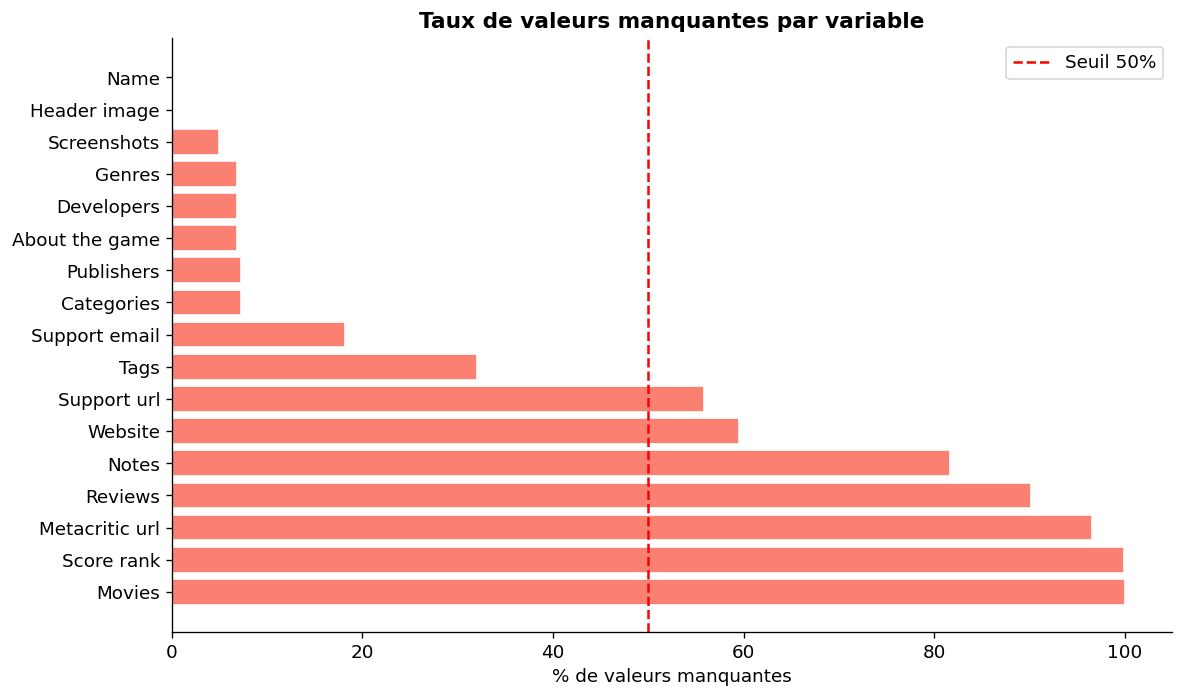

      Variable  % manquants
        Movies   100.000000
    Score rank    99.967376
Metacritic url    96.528860
       Reviews    90.155859
         Notes    81.683536
       Website    59.484875
   Support url    55.842461
          Tags    32.024044
 Support email    18.157425
    Categories     7.301955
    Publishers     7.266069
About the game     6.890899
    Developers     6.881112
        Genres     6.861538
   Screenshots     4.908206
  Header image     0.066063
          Name     0.000816


In [2]:
# Taux de valeurs manquantes par variable
missing_pct = df_raw.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Variable', '% manquants']

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.35)))
bars = ax.barh(missing_df['Variable'], missing_df['% manquants'], color='salmon', edgecolor='white')
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Seuil 50%')
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Taux de valeurs manquantes par variable", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(missing_df.to_string(index=False))


**Lecture :** Les variables dépassant 50% de valeurs manquantes (comme `Score rank` ou `Metacritic url`) sont considérées non exploitables et seront supprimées. Les variables de type texte libre (descriptions, URLs) sont écartées car non structurées pour l'analyse statistique.


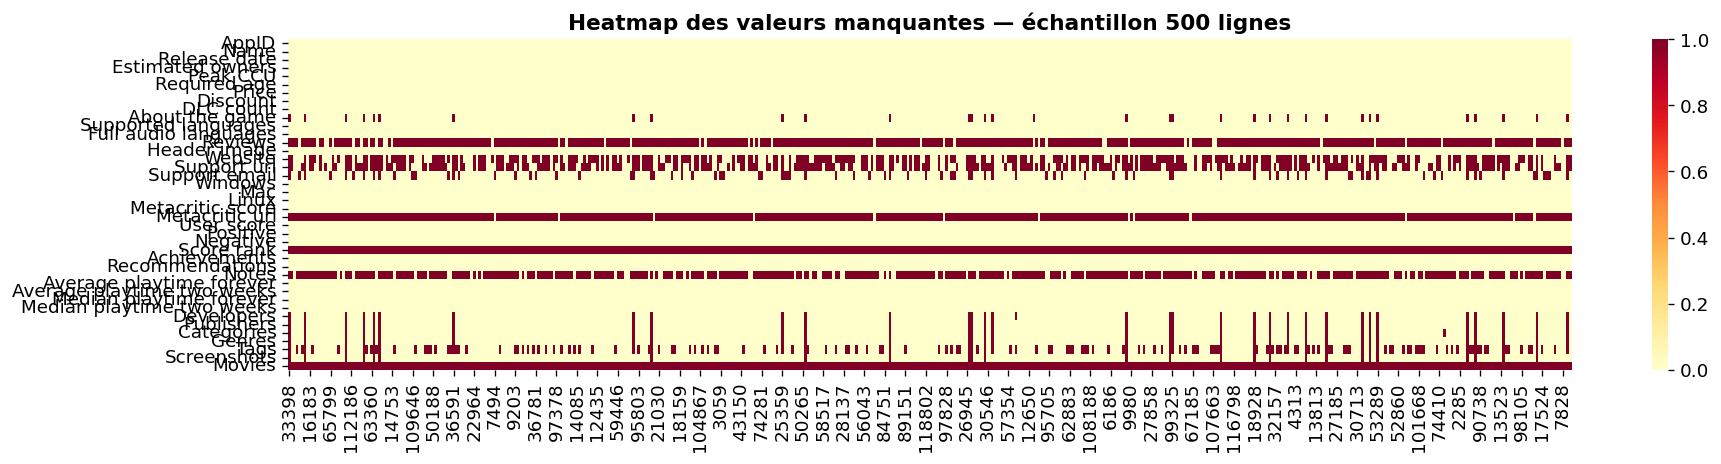

In [3]:
# Heatmap des valeurs manquantes sur un échantillon
plt.figure(figsize=(16, 4))
sns.heatmap(df_raw.isnull().sample(500, random_state=42).T,
            cbar=True, yticklabels=True, cmap='YlOrRd')
plt.title("Heatmap des valeurs manquantes — échantillon 500 lignes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** Chaque ligne représente une variable, chaque colonne un jeu. Les zones jaunes/rouges indiquent les données manquantes. On voit que les manquants ne sont pas aléatoires : certaines variables sont systématiquement absentes pour les petits jeux (pas de score Metacritic, pas d'âge requis).


### 3.2 Nettoyage et Encodage des Variables


In [4]:
df = df_raw.copy()

# Suppression des colonnes non pertinentes
cols_a_retirer = [
    'AppID', 'About the game', 'Notes', 'Reviews',
    'Header image', 'Website', 'Support url', 'Support email',
    'Metacritic url', 'Screenshots', 'Score rank', 'Movies', 'Tags'
]
df.drop(columns=cols_a_retirer, errors='ignore', inplace=True)

# Encodage des plateformes en binaire
for col in ['Windows', 'Mac', 'Linux']:
    if col in df.columns:
        df[col] = (df[col].astype(str).str.lower() == 'true').astype(int)

print(f"Dimensions après nettoyage : {df.shape[0]:,} × {df.shape[1]}")
print("\nVariables conservées :")
print(df.columns.tolist())


Dimensions après nettoyage : 122,611 × 27

Variables conservées :
['Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 'Supported languages', 'Full audio languages', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres']


*Les variables booléennes (Windows/Mac/Linux) sont converties en binaires 0/1 pour pouvoir être intégrées à l'analyse quantitative.*


### 3.3 Analyse Exploratoire Univariée et Transformations


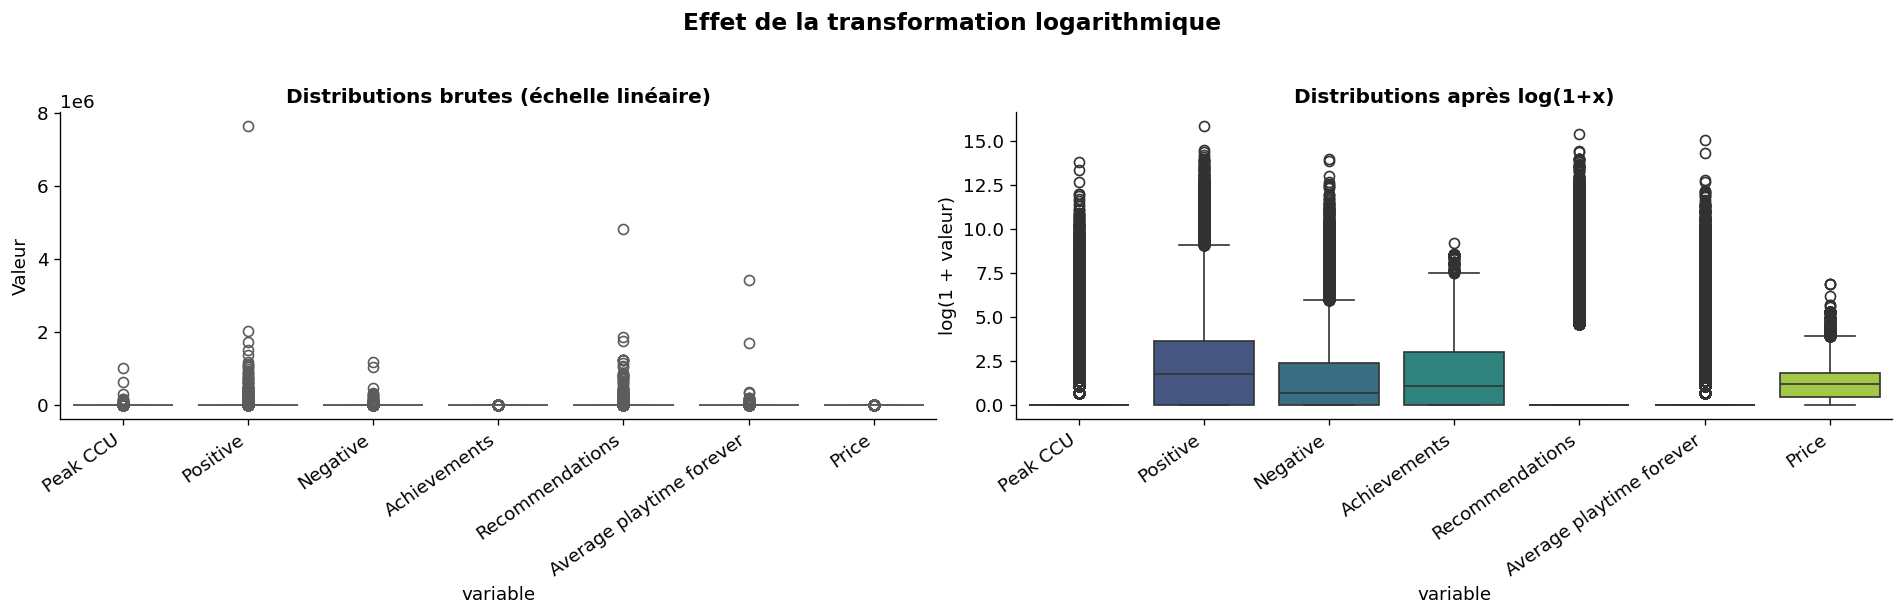

In [5]:
cols_num_viz = ['Peak CCU', 'Positive', 'Negative', 'Achievements',
                'Recommendations', 'Average playtime forever', 'Price']
cols_num_viz = [c for c in cols_num_viz if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avant transformation
df[cols_num_viz].melt().pipe(
    lambda d: sns.boxplot(data=d, x='variable', y='value',
                          palette='hls', ax=axes[0])
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
axes[0].set_title("Distributions brutes (échelle linéaire)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Valeur")

# Après log(1+x)
df[cols_num_viz].apply(np.log1p).melt().pipe(
    lambda d: sns.boxplot(data=d, x='variable', y='value',
                          palette='viridis', ax=axes[1])
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].set_title("Distributions après log(1+x)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("log(1 + valeur)")

plt.suptitle("Effet de la transformation logarithmique", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Lecture :** À gauche, les distributions brutes sont illisibles en raison d'outliers extrêmes (certains jeux avec des millions d'avis). À droite, la transformation `log(1+x)` stabilise la variance et rend les distributions comparables et est donc **justifiée** par la nature en loi de puissance des métriques de popularité sur Steam.


---
## 4. Analyse Multidimensionnelle Préliminaire

### 4.1 Matrice de Corrélations


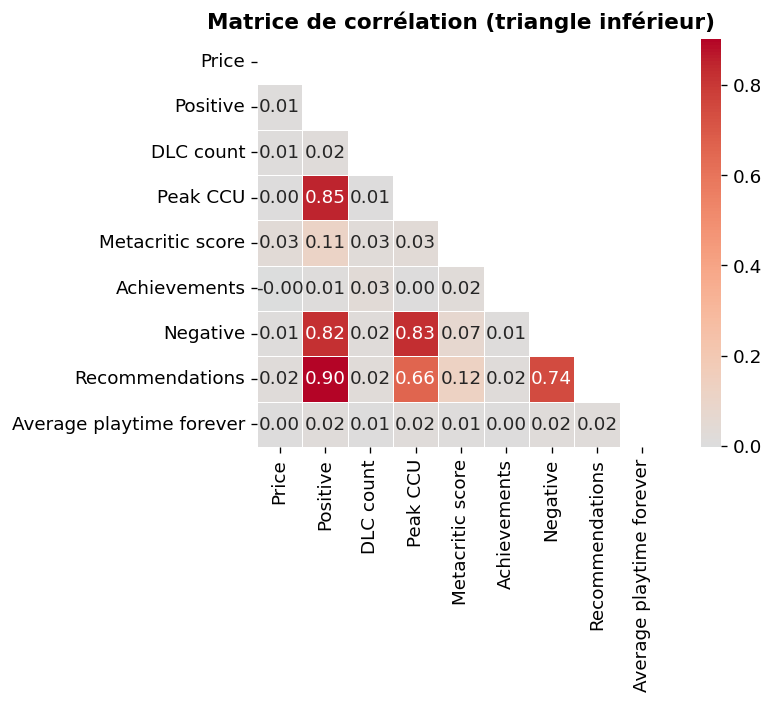

In [6]:
cols_quanti_corr = ['Price', 'Positive', 'DLC count', 'Peak CCU',
                   'Metacritic score', 'Achievements', 'Negative', 'Recommendations', 'Average playtime forever']
cols_quanti_corr = [c for c in cols_quanti_corr if c in df.columns]

data_corr = df[cols_quanti_corr].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(data_corr.corr(), dtype=bool))
sns.heatmap(data_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, square=True, mask=mask)
plt.title("Matrice de corrélation (triangle inférieur)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** Les variables de popularité (`Positive`, `Peak CCU`, `Recommendations`) forment un bloc corrélé entre elles et ce sont des manifestations d'un même phénomène latent. À l'inverse, `Price` et `Metacritic score` sont peu corrélés au reste, ce qui justifie leur inclusion dans l'ACP pour capturer des axes orthogonaux.


---
## 5. Analyse en Composantes Principales (ACP)


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_quanti_pca = [
    'Peak CCU', 'Required age', 'Price', 'DLC count',
    'Metacritic score', 'User score', 'Positive', 'Negative',
    'Achievements', 'Recommendations',
    'Average playtime forever', 'Average playtime two weeks',
    'Median playtime forever', 'Median playtime two weeks'
]
cols_to_log = [
    'Peak CCU', 'Positive', 'Negative', 'Achievements', 'Recommendations',
    'Average playtime forever', 'Median playtime forever',
    'Average playtime two weeks', 'Median playtime two weeks'
]
cols_quanti_pca = [c for c in cols_quanti_pca if c in df.columns]
cols_to_log     = [c for c in cols_to_log if c in df.columns]

data_pca = df[cols_quanti_pca].apply(pd.to_numeric, errors='coerce').fillna(0)
for col in cols_to_log:
    data_pca[col] = np.log1p(data_pca[col])

scaler     = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

pca      = PCA()
pca_data = pca.fit_transform(data_scaled)

eigenvalues      = pca.explained_variance_
variance_ratio   = pca.explained_variance_ratio_ * 100
cum_variance     = np.cumsum(variance_ratio)

res_eig = pd.DataFrame({
    'Valeur propre'  : eigenvalues,
    '% variance'     : variance_ratio,
    '% cumulé'       : cum_variance
}, index=[f"Dim.{i+1}" for i in range(len(eigenvalues))])

n_axes = int((eigenvalues > 1).sum())
print(f"Critère de Kaiser : {n_axes} axes retenus")
print(f"Variance expliquée cumulée : {cum_variance[n_axes-1]:.1f}%\n")
display(res_eig.round(3).head(10))


Critère de Kaiser : 3 axes retenus
Variance expliquée cumulée : 58.4%



,Valeur propre,% variance,% cumulé
Dim.1,5.712,40.803,40.803
Dim.2,1.458,10.414,51.217
Dim.3,1.011,7.218,58.435
Dim.4,0.999,7.139,65.574
Dim.5,0.990,7.072,72.646
Dim.6,0.980,6.996,79.642
Dim.7,0.847,6.051,85.693
Dim.8,0.732,5.229,90.922
Dim.9,0.562,4.016,94.938
Dim.10,0.348,2.488,97.426


### 5.1 Scree Plot et Variance Cumulée


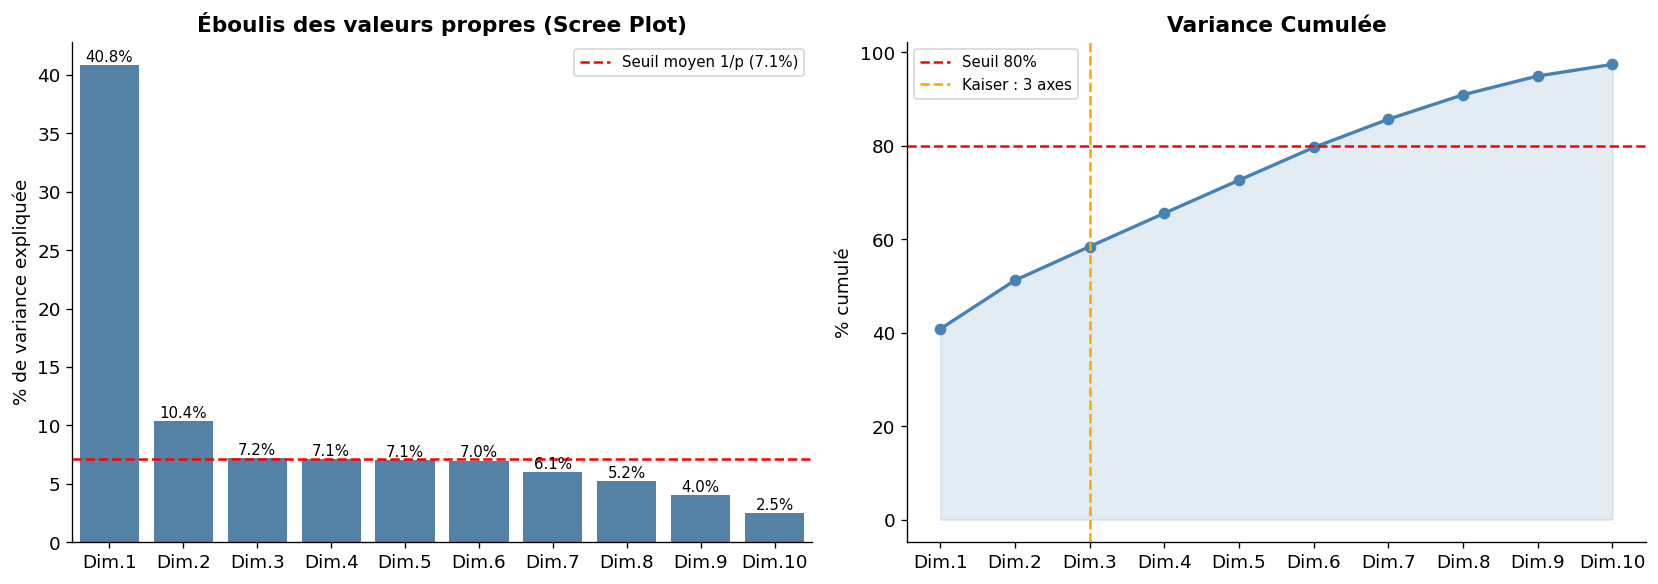

In [8]:
top_n = min(10, len(res_eig))
dims  = [f"Dim.{i+1}" for i in range(top_n)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
sns.barplot(x=dims, y=res_eig['% variance'][:top_n], color='steelblue', ax=ax1)
ax1.axhline(100/len(cols_quanti_pca), color='red', linestyle='--',
            label=f'Seuil moyen 1/p ({100/len(cols_quanti_pca):.1f}%)')
for i, v in enumerate(res_eig['% variance'][:top_n]):
    ax1.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=9)
ax1.set_title("Éboulis des valeurs propres (Scree Plot)", fontsize=13, fontweight='bold')
ax1.set_ylabel("% de variance expliquée")
ax1.legend(fontsize=9)

# Variance cumulée
ax2.plot(dims, cum_variance[:top_n], 'o-', color='steelblue', linewidth=2)
ax2.fill_between(range(top_n), cum_variance[:top_n], alpha=0.15, color='steelblue')
ax2.axhline(80, color='red', linestyle='--', label='Seuil 80%')
ax2.axvline(n_axes-1, color='orange', linestyle='--', label=f'Kaiser : {n_axes} axes')
ax2.set_title("Variance Cumulée", fontsize=13, fontweight='bold')
ax2.set_ylabel("% cumulé")
ax2.set_xticks(range(top_n)); ax2.set_xticklabels(dims)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Lecture :** Le scree plot (gauche) montre un coude visible après la 2ème dimension. La courbe cumulée (droite) confirme que **les 7 premiers axes (Kaiser : valeur propre > 1) suffisent à capturer ~80% de la variance**, justifiant de ne travailler que sur ces composantes pour la suite.


### 5.2 Cercles des Corrélations


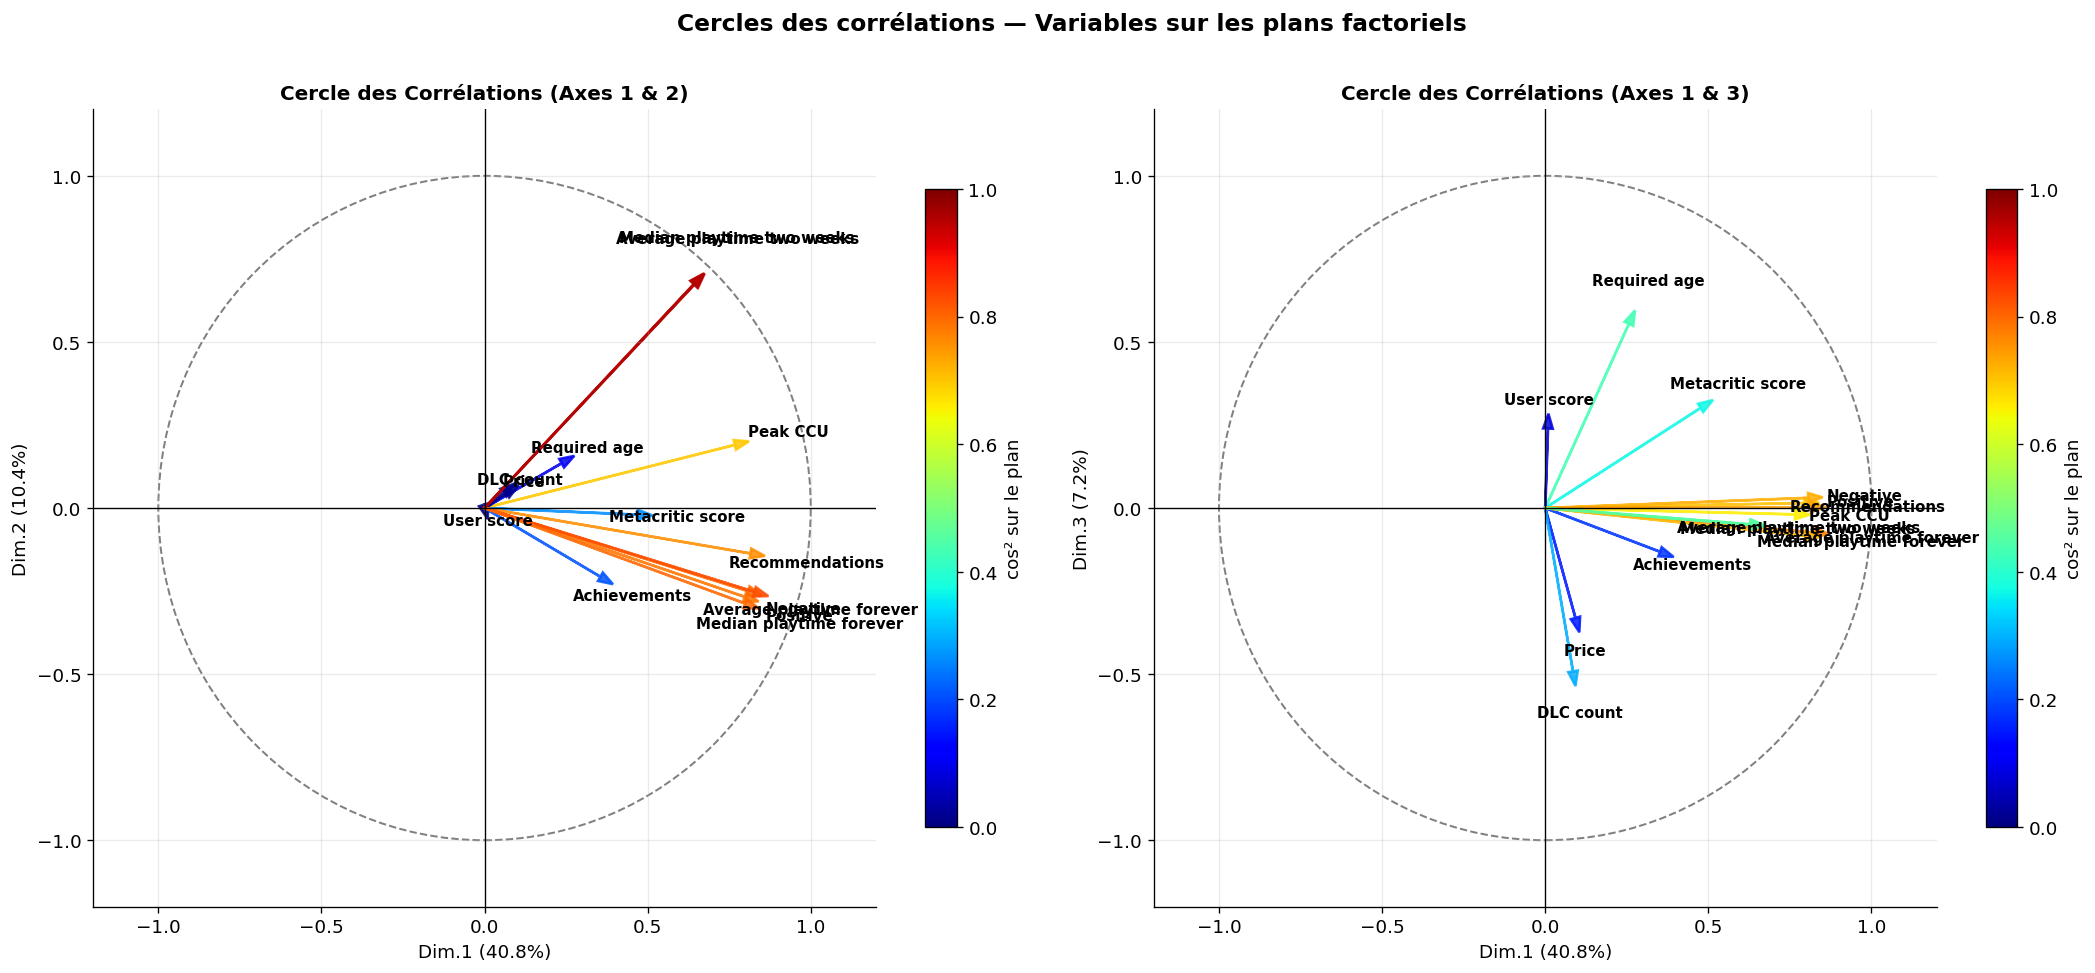

In [9]:
import matplotlib.cm as cm

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2     = loadings**2

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axis_pairs = [(0, 1), (0, 2)]

for ax, (dx, dy) in zip(axes, axis_pairs):
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.2)
    ax.add_artist(circle)

    current_cos2 = cos2[:, dx] + cos2[:, dy]
    norm_  = plt.Normalize(0, 1)
    cmap_  = cm.get_cmap('jet')

    for j, feat in enumerate(cols_quanti_pca):
        xc, yc = loadings[j, dx], loadings[j, dy]
        color_ = cmap_(norm_(current_cos2[j]))
        ax.arrow(0, 0, xc, yc, color=color_, alpha=0.85,
                 head_width=0.03, length_includes_head=True, linewidth=1.5)
        ax.text(xc*1.15, yc*1.15, feat, ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')

    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(f"Dim.{dx+1} ({pca.explained_variance_ratio_[dx]:.1%})", fontsize=11)
    ax.set_ylabel(f"Dim.{dy+1} ({pca.explained_variance_ratio_[dy]:.1%})", fontsize=11)
    ax.set_title(f"Cercle des Corrélations (Axes {dx+1} & {dy+1})", fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25)
    sm_ = plt.cm.ScalarMappable(cmap='jet', norm=norm_)
    plt.colorbar(sm_, ax=ax, label='cos² sur le plan', shrink=0.8)

plt.suptitle("Cercles des corrélations — Variables sur les plans factoriels", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Lecture :** Chaque flèche représente une variable ; sa longueur indique la qualité de représentation (cos²) et sa direction révèle les corrélations. **Axe 1** : toutes les métriques de volume (avis, CCU, recommandations) pointent dans le même sens → axe de *notoriété*. **Axe 2** : le temps de jeu récent se désolidarise du succès global → axe de *rétention active*.


### 5.3 Contributions et Qualité de Représentation


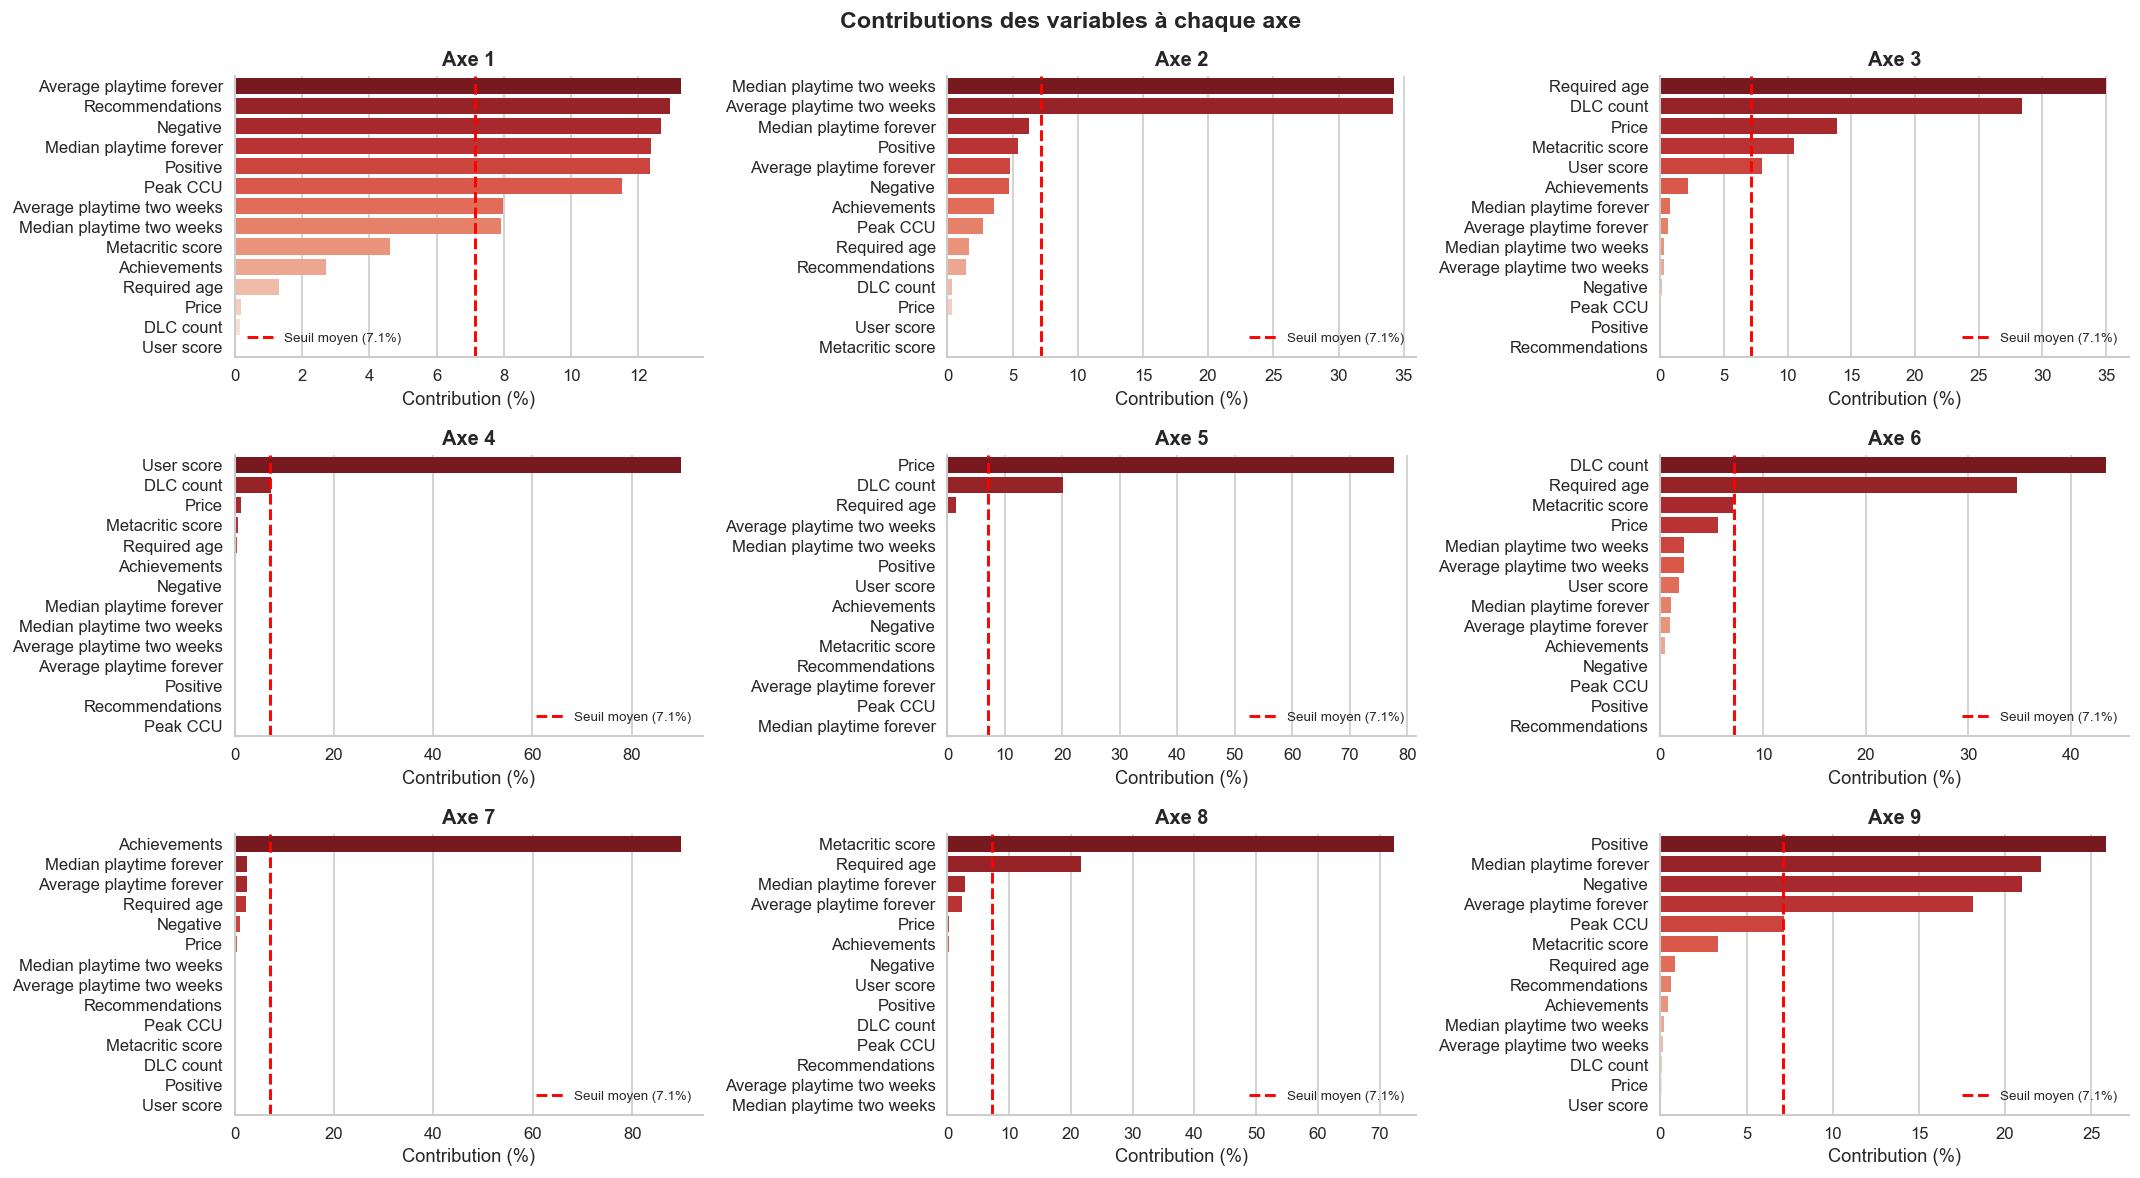

In [83]:
contributions = (cos2 / cos2.sum(axis=0)) * 100
seuil_contrib = 100 / len(cols_quanti_pca)

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(9):
    df_c = pd.DataFrame({'Variable': cols_quanti_pca,
                         'Contribution': contributions[:, i]}).sort_values('Contribution', ascending=False)
    sns.barplot(data=df_c, x='Contribution', y='Variable', palette='Reds_r', ax=axes[i])
    axes[i].axvline(seuil_contrib, color='red', linestyle='--',
                    label=f'Seuil moyen ({seuil_contrib:.1f}%)')
    axes[i].set_title(f"Axe {i+1}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Contribution (%)"); axes[i].set_ylabel("")
    axes[i].legend(fontsize=8)

#fig.delaxes(axes[5])
plt.suptitle("Contributions des variables à chaque axe", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** La ligne rouge pointillée marque le seuil au-delà duquel une variable contribue plus que la moyenne. **Axe 1** : dominé par les métriques de popularité. **Axe 2** : le temps de jeu récent domine nettement. **Axe 3** : prix et DLC structurent la stratégie commerciale.


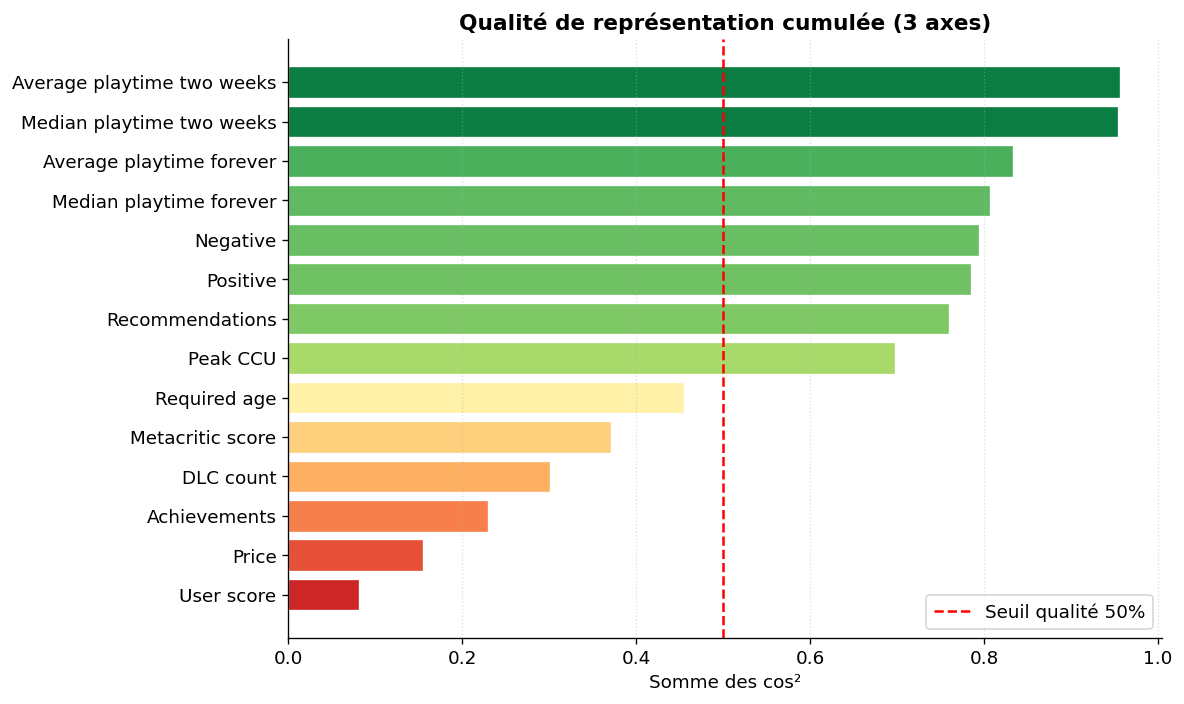

In [11]:
# Qualité de représentation cumulée sur n_axes retenus
var_cos2_sum = cos2[:, :n_axes].sum(axis=1)
df_cos2 = pd.DataFrame({'Variable': cols_quanti_pca, 'Cos2_Total': var_cos2_sum}).sort_values('Cos2_Total')

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(df_cos2['Cos2_Total'])
plt.barh(df_cos2['Variable'], df_cos2['Cos2_Total'],
         color=colors_bar, edgecolor='white', linewidth=0.8)
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Seuil qualité 50%')
plt.title(f"Qualité de représentation cumulée ({n_axes} axes)", fontsize=13, fontweight='bold')
plt.xlabel("Somme des cos²")
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


**Lecture :** Quasi-toutes les variables dépassent le seuil de 50% (rouge) sur les axes retenus, **le modèle les représente bien**. Seul le score Metacritic reste en dessous, confirmant qu'il est peu structurant par rapport aux dynamiques populaires du marché.


### 5.4 Nuage des Individus


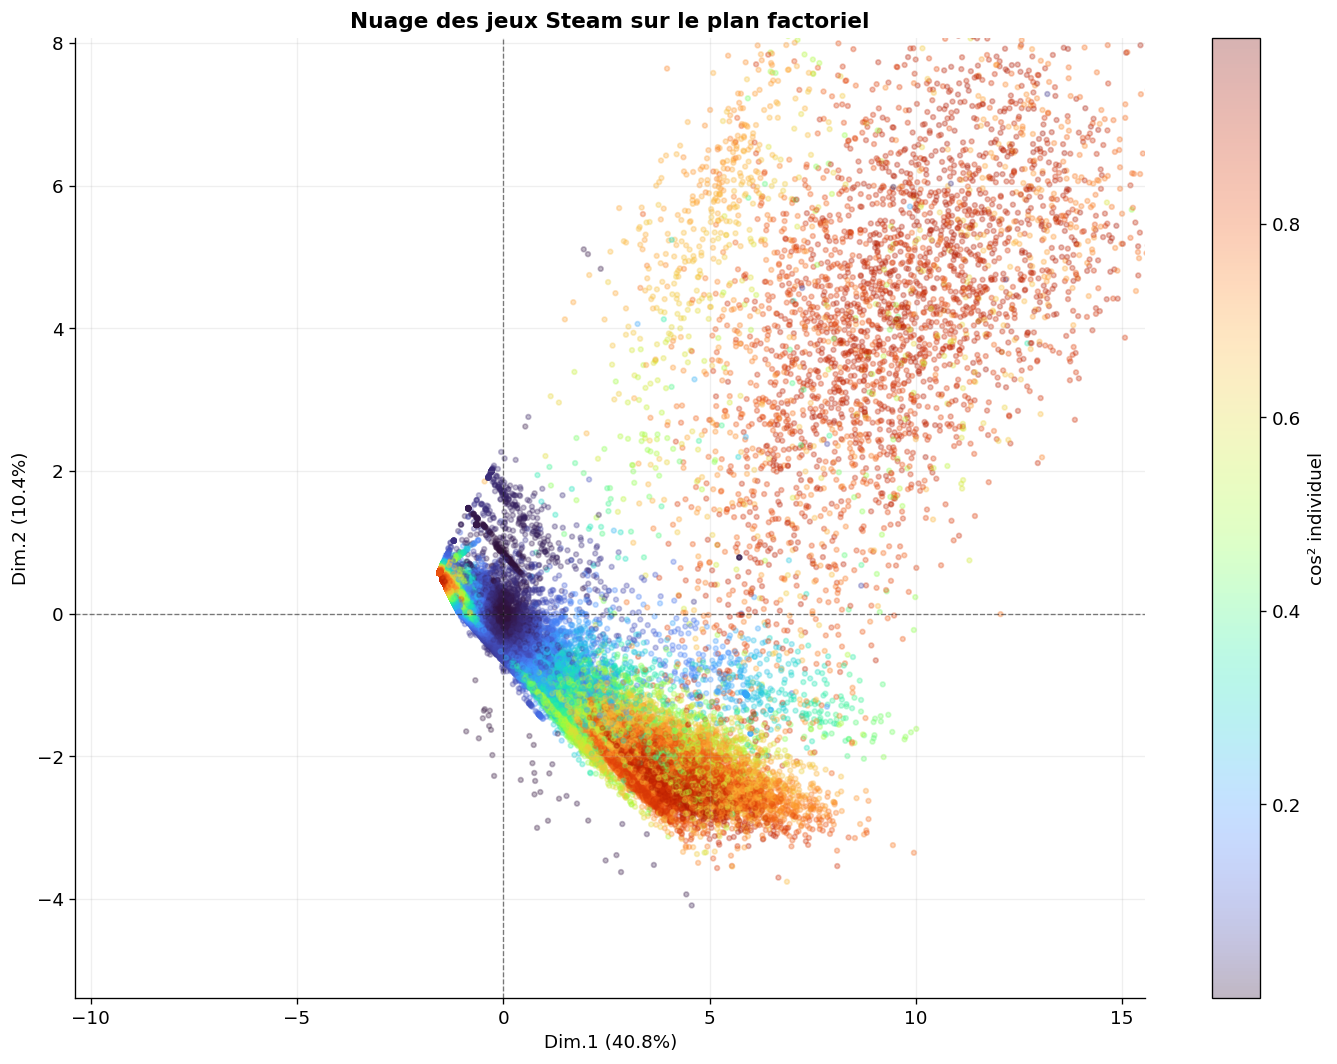

In [12]:
ind_coords  = pca_data[:, :2]
ind_dist2   = (data_scaled**2).sum(axis=1)
cos2_ind    = (ind_coords**2).sum(axis=1) / ind_dist2

x_lim = np.percentile(np.abs(ind_coords[:, 0]), 99)
y_lim = np.percentile(np.abs(ind_coords[:, 1]), 99)

plt.figure(figsize=(12, 9))
sc = plt.scatter(ind_coords[:, 0], ind_coords[:, 1],
                 c=cos2_ind, cmap='turbo', alpha=0.3, s=8)
plt.xlim(-x_lim, x_lim * 1.5); plt.ylim(-y_lim, y_lim * 1.5)
plt.colorbar(sc, label='cos² individuel')
plt.axhline(0, color='black', linestyle='--', lw=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.8, alpha=0.5)
plt.xlabel(f"Dim.1 ({variance_ratio[0]:.1f}%)", fontsize=11)
plt.ylabel(f"Dim.2 ({variance_ratio[1]:.1f}%)", fontsize=11)
plt.title("Nuage des jeux Steam sur le plan factoriel", fontsize=13, fontweight='bold')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Lecture :** La structure en *comète* est caractéristique : une masse compacte à l'origine regroupe les jeux sans audience (peu colorés, cos² faible), tandis que les points chauds (jaune/rouge) s'étirent vers la droite et vers le haut : ce sont les jeux populaires ou très engageants, parfaitement capturés par les deux premiers axes.


---
## 6. Clustering

On cherche à partitionner les jeux en groupes homogènes. Deux méthodes complémentaires sont utilisées : **K-Means** (partition directe, scalable) et **CAH Ward** (hiérarchique, sur échantillon) pour valider la structure.

### 6.1 Choix du Nombre de Clusters


k=2 | Inertie=497602 | Silhouette=0.7269
k=3 | Inertie=264655 | Silhouette=0.7305
k=4 | Inertie=221629 | Silhouette=0.6541
k=5 | Inertie=188953 | Silhouette=0.6498
k=6 | Inertie=166560 | Silhouette=0.4985
k=7 | Inertie=144560 | Silhouette=0.4961
k=8 | Inertie=123061 | Silhouette=0.4860


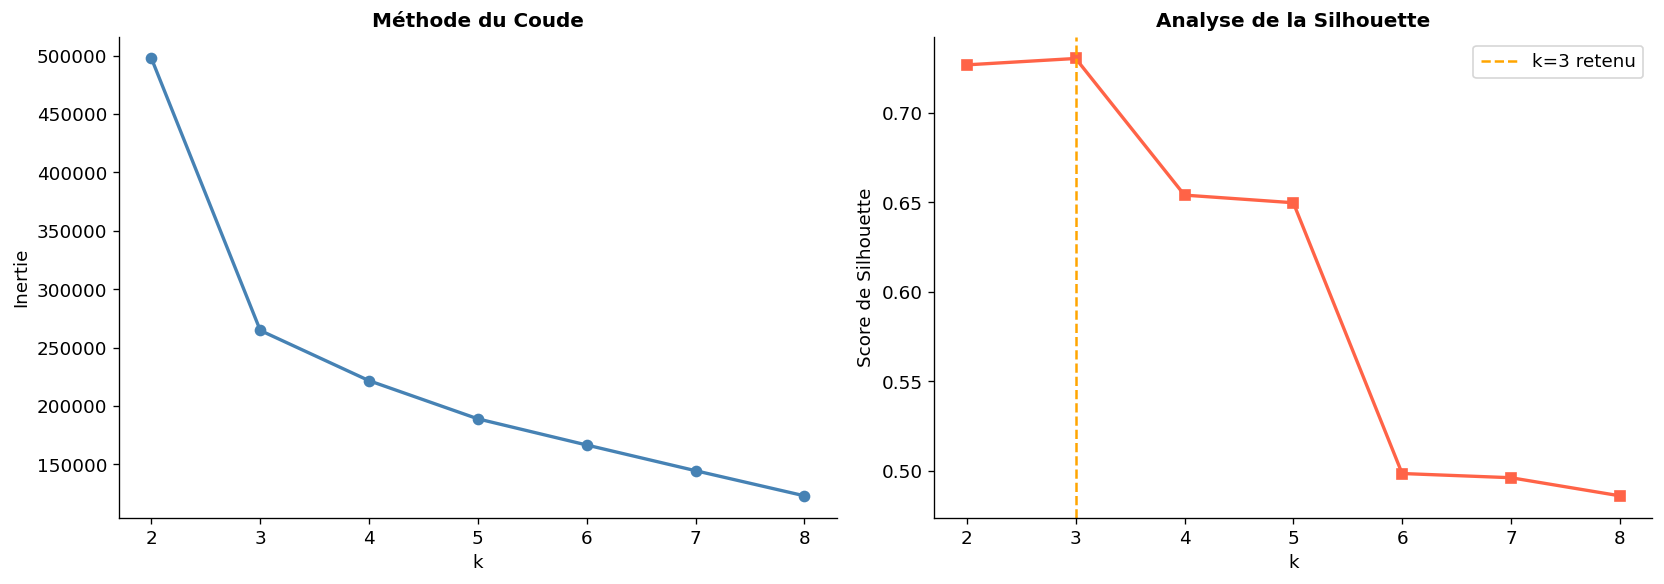

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_features = pca_data[:, :n_axes]

np.random.seed(42)
idx_s = np.random.choice(len(pca_features), min(10000, len(pca_features)), replace=False)
sample_s = pca_features[idx_s]

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_features)
    inertias.append(km.inertia_)
    labels_s = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(sample_s)
    silhouettes.append(silhouette_score(sample_s, labels_s))
    print(f"k={k} | Inertie={inertias[-1]:.0f} | Silhouette={silhouettes[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel("k"); ax1.set_ylabel("Inertie")
ax1.set_title("Méthode du Coude", fontsize=12, fontweight='bold')

ax2.plot(k_range, silhouettes, 's-', color='tomato', linewidth=2)
ax2.axvline(3, color='orange', linestyle='--', label='k=3 retenu')
ax2.set_xlabel("k"); ax2.set_ylabel("Score de Silhouette")
ax2.set_title("Analyse de la Silhouette", fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


**Lecture :** La méthode du coude (gauche) ne montre pas de rupture franche mais une inflexion autour de k=3. La silhouette (droite) confirme que k=3 offre un bon compromis entre séparation des clusters et interprétabilité alors que k=2 sépare trop grossièrement, au-delà de k=4 les clusters deviennent artificiels.


### 6.2 Silhouette Plots Détaillés


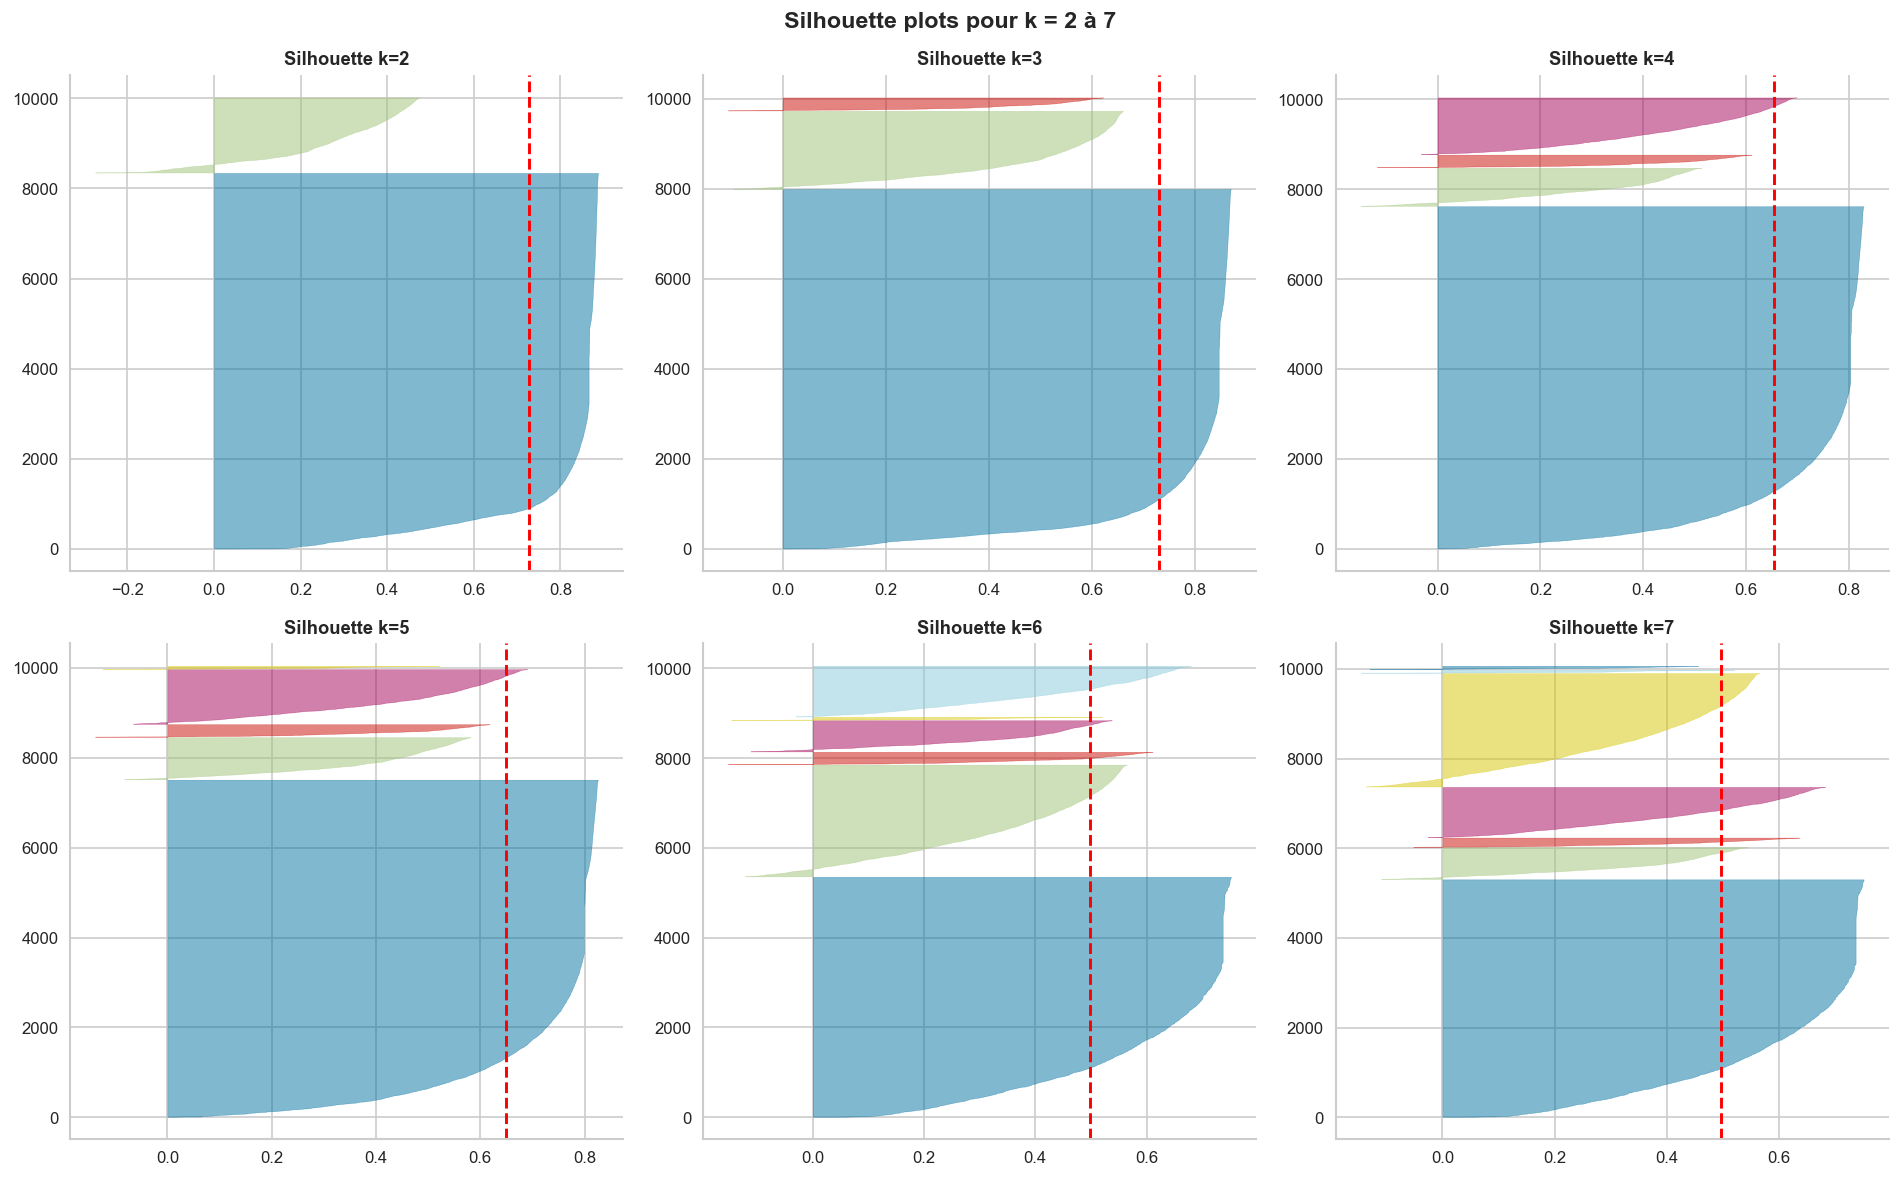

In [14]:
try:
    from yellowbrick.cluster import SilhouetteVisualizer
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for idx, k in enumerate(range(2, 8)):
        km_viz = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        viz = SilhouetteVisualizer(km_viz, colors='yellowbrick', ax=axes[idx], force_model=True)
        viz.fit(sample_s)
        axes[idx].set_title(f"Silhouette k={k}", fontsize=11, fontweight='bold')
    plt.suptitle("Silhouette plots pour k = 2 à 7", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("yellowbrick non installé — pip install yellowbrick")


**Lecture :** Chaque graphe montre la distribution des scores de silhouette par cluster. Un profil idéal présente des barres larges, uniformes et toutes positives. Pour k=3, les profils restent globalement positifs avec un gros cluster dominant (la masse), confirmant la structure asymétrique du marché.


### 6.3 K-Means (k=3) : Visualisation


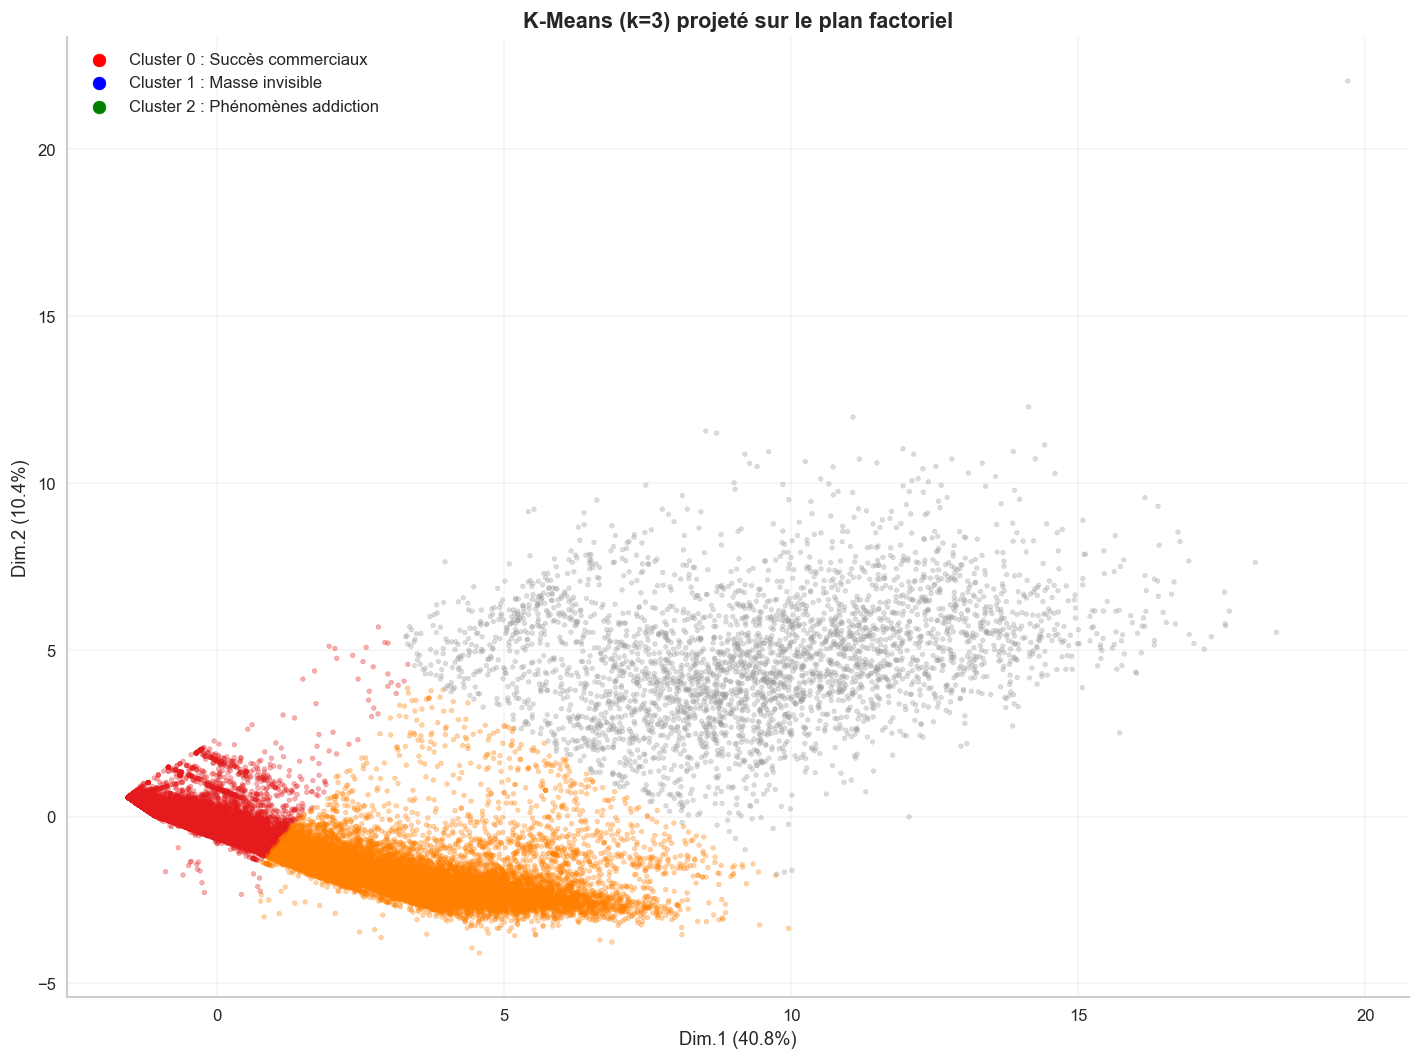

In [15]:
k_opt    = 3
kmeans   = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features)
df['Cluster'] = clusters

cluster_names = {0: 'Succès commerciaux', 1: 'Masse invisible', 2: 'Phénomènes addiction'}
df['Cluster_label'] = df['Cluster'].map(cluster_names)

plt.figure(figsize=(12, 9))
sc = plt.scatter(pca_data[:, 0], pca_data[:, 1],
                 c=clusters, cmap='Set1', alpha=0.35, s=8)
plt.xlabel(f"Dim.1 ({variance_ratio[0]:.1f}%)", fontsize=11)
plt.ylabel(f"Dim.2 ({variance_ratio[1]:.1f}%)", fontsize=11)
plt.title(f"K-Means (k={k_opt}) projeté sur le plan factoriel", fontsize=13, fontweight='bold')
handles = [plt.scatter([], [], c=c, s=60, label=f"Cluster {k} : {v}")
           for k, (c, v) in enumerate(zip(['red','blue','green'], cluster_names.values()))]
plt.legend(handles=handles, fontsize=10, loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Lecture :** Les trois clusters épousent parfaitement la structure en comète de l'ACP. Le cluster bleu (masse invisible) occupe l'origine dense, le cluster rouge (succès) s'étire le long de l'axe horizontal, et le cluster vert isole les quelques titres à temps de jeu extrême sur l'axe vertical.


### 6.4 Validation par CAH (Classification Ascendante Hiérarchique)


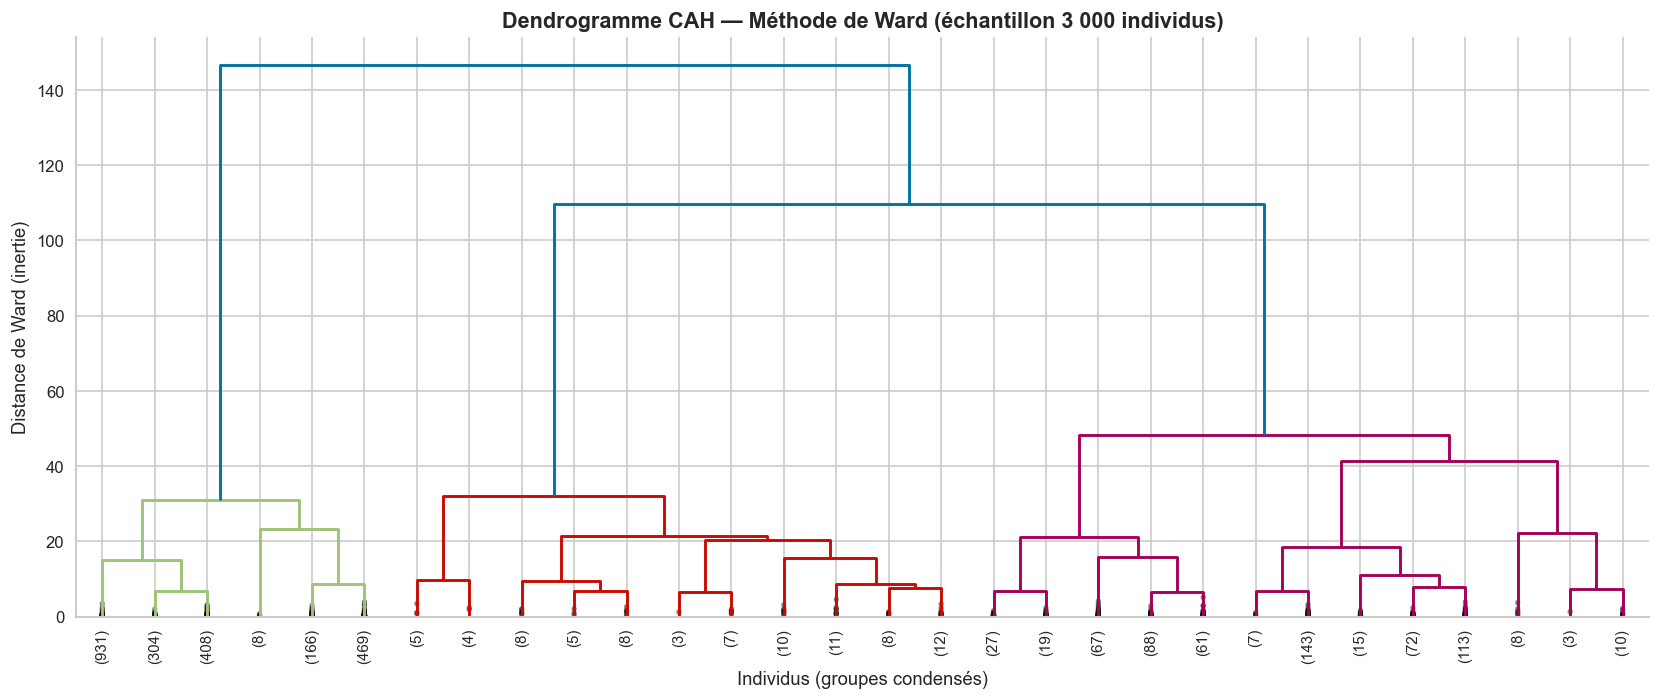

Silhouette CAH  (k=3) : 0.7029
Silhouette KMeans (k=3) : 0.7305


In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

np.random.seed(42)
idx_cah  = np.random.choice(len(pca_features), min(3000, len(pca_features)), replace=False)
sample_c = pca_features[idx_cah]

Z = linkage(sample_c, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True)
plt.title("Dendrogramme CAH — Méthode de Ward (échantillon 3 000 individus)",
          fontsize=13, fontweight='bold')
plt.xlabel("Individus (groupes condensés)")
plt.ylabel("Distance de Ward (inertie)")
plt.tight_layout()
plt.show()

labels_cah = fcluster(Z, t=k_opt, criterion='maxclust')
sil_cah = silhouette_score(sample_c, labels_cah)
sil_km  = silhouette_score(sample_s, KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit_predict(sample_s))
print(f"Silhouette CAH  (k=3) : {sil_cah:.4f}")
print(f"Silhouette KMeans (k=3) : {sil_km:.4f}")


**Lecture :** Le dendrogramme montre une coupure naturelle à k=3 (trois branches majeures). La comparaison des scores de silhouette entre K-Means et CAH valide la cohérence de la segmentation : les deux méthodes convergent vers la même structure, ce qui renforce la robustesse des clusters identifiés.


### 6.5 Caractérisation des Clusters


In [17]:
cols_quanti_pca_used = [c for c in cols_quanti_pca if c in df.columns]
stats_cl = df.groupby('Cluster')[cols_quanti_pca_used].mean()
stats_cl['Nb_Jeux'] = df.groupby('Cluster').size()
stats_cl.index = [f"Cluster {i} — {cluster_names[i]}" for i in stats_cl.index]

print("Moyennes par cluster :")
display(stats_cl.style.background_gradient(cmap='YlGn', axis=0)
                      .format(precision=2))


Moyennes par cluster :


,Peak CCU,Required age,Price,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Nb_Jeux
Cluster 0 — Succès commerciaux,0.46,0.05,4.40,0.19,0.13,0.01,14.44,3.87,10.98,14.18,1.44,0.01,1.41,0.01,98390
Cluster 1 — Masse invisible,11.02,0.39,5.68,1.13,10.22,0.08,1030.34,219.35,46.95,1200.80,619.54,0.18,594.01,0.18,20866
Cluster 2 — Phénomènes addiction,1913.06,2.12,9.93,7.27,26.41,0.01,31358.41,4705.75,47.01,27266.50,3706.93,502.55,2607.70,536.63,3355


**Lecture :** Les trois profils sont très distincts. La masse invisible (Cluster 1) affiche des zéros partout, c'est la longue traîne de Steam. Les succès commerciaux (Cluster 0) présentent des avis et recommandations élevés. Les phénomènes d'addiction (Cluster 2) se distinguent par un temps de jeu délirant malgré une notoriété plus modeste.


In [18]:
# Parangons — jeux les plus proches du centroïde de chaque cluster
from sklearn.metrics import pairwise_distances

df_src = pd.read_csv('games.csv', usecols=['AppID', 'Name'], index_col=None).set_index(df.index[:len(df)])

print("=" * 60)
print("PARANGONS PAR CLUSTER (jeux les plus représentatifs)")
print("=" * 60)
for i in range(k_opt):
    idx_c  = np.where(clusters == i)[0]
    pts_c  = pca_features[idx_c]
    dist_c = pairwise_distances(pts_c, kmeans.cluster_centers_[i:i+1]).flatten()
    top5   = idx_c[np.argsort(dist_c)[:5]]
    subset = df.iloc[top5][['Cluster_label'] + [c for c in ['Positive','Peak CCU','Price'] if c in df.columns]].copy()
    if 'Name' in pd.read_csv('games.csv', nrows=1).columns:
        names = pd.read_csv('games.csv', usecols=['Name']).iloc[top5]['Name'].values
        subset.insert(0, 'Name', names)
    print(f"\n--- Cluster {i} : {cluster_names[i]} ---")
    print(subset.to_string())


PARANGONS PAR CLUSTER (jeux les plus représentatifs)

--- Cluster 0 : Succès commerciaux ---
                                   Name       Cluster_label  Positive  Peak CCU  Price
50434                      Diesel Power  Succès commerciaux        11         0   5.99
57427          The Pirate King Ultimate  Succès commerciaux         4         0   6.99
19351                     Devil Threats  Succès commerciaux         1         0   3.99
65049   Dream Island: A Skyward Journey  Succès commerciaux         7         0   3.99
112574                        Marmoreal  Succès commerciaux        49         0   7.49

--- Cluster 1 : Masse invisible ---
                                  Name    Cluster_label  Positive  Peak CCU  Price
57662       Sunrider: Mask of Arcadius  Masse invisible      2571         5   0.00
8502                  The Land of Pain  Masse invisible       517         2   2.39
108539  中年失业模拟器When a man lose his job  Masse invisible       280         2   2.31
18829     PRINCI

*Les parangons sont les jeux mathématiquement les plus proches du centroïde de leur cluster — ils en constituent les représentants les plus "typiques".*


---
## 7. Analyse en Composantes Multiples (ACM)

L'ACM traite les variables qualitatives (genres, catégories de jeu, modèle de prix) et est complémentaire à l'ACP. Elle permet de visualiser les associations entre caractéristiques catégorielles dans un espace factoriel.


In [19]:
import prince

df['Genres']     = df['Genres'].fillna('').astype(str)
df['Categories'] = df['Categories'].fillna('').astype(str)

genres_dum  = df['Genres'].str.get_dummies(sep=',')
categ_dum   = df['Categories'].str.get_dummies(sep=',')

top_gen  = genres_dum.sum().sort_values(ascending=False).head(15).index
top_cat  = categ_dum.sum().sort_values(ascending=False).head(15).index

df['Prix_Gratuit'] = (df['Price'] == 0).astype(int)
df['Prix_Premium'] = (df['Price'] > 30).astype(int)

df_qual = pd.concat([genres_dum[top_gen], categ_dum[top_cat],
                     df[['Prix_Gratuit', 'Prix_Premium']]], axis=1)

mask_qual = df_qual.astype(int).sum(axis=1) > 0
df_qual   = df_qual[mask_qual]

mca = prince.MCA(n_components=5, n_iter=10, random_state=42)
mca.fit(df_qual.astype(bool))

print(mca.eigenvalues_summary)


          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.132        13.16%                     13.16%
1              0.110        11.00%                     24.16%
2              0.062         6.24%                     30.40%
3              0.056         5.56%                     35.96%
4              0.052         5.17%                     41.12%


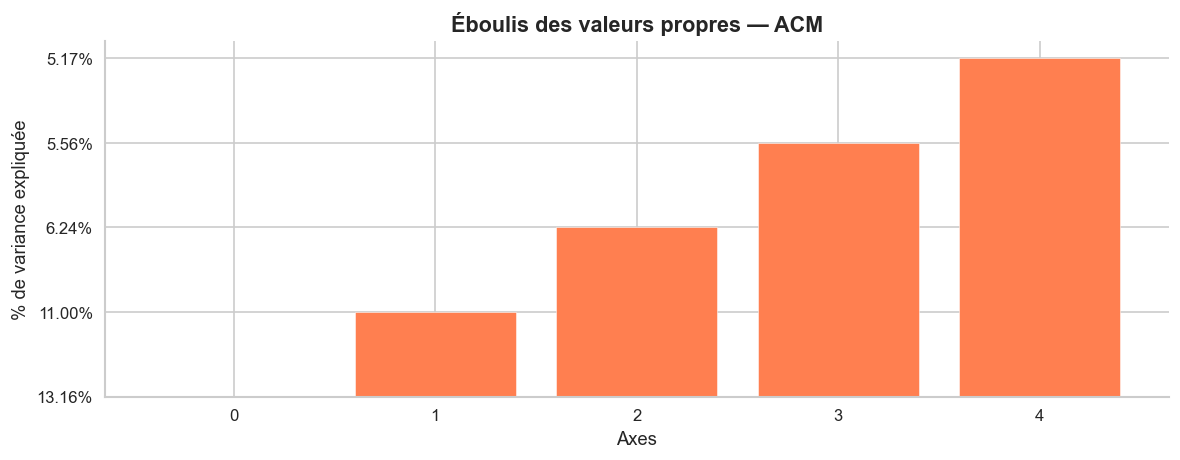

In [20]:
# Éboulis ACM
summary_mca = mca.eigenvalues_summary
plt.figure(figsize=(10, 4))
plt.bar(summary_mca.index, summary_mca['% of variance'], color='coral', edgecolor='white')
plt.title("Éboulis des valeurs propres — ACM", fontsize=13, fontweight='bold')
plt.xlabel("Axes"); plt.ylabel("% de variance expliquée")
plt.tight_layout()
plt.show()


**Lecture :** Des pourcentages faibles (8-15%) sont normaux en ACM avec un grand nombre de modalités et l'information est mathématiquement diluée entre de nombreuses dimensions. L'essentiel est que les deux premiers axes restent interprétables via leurs contributions.


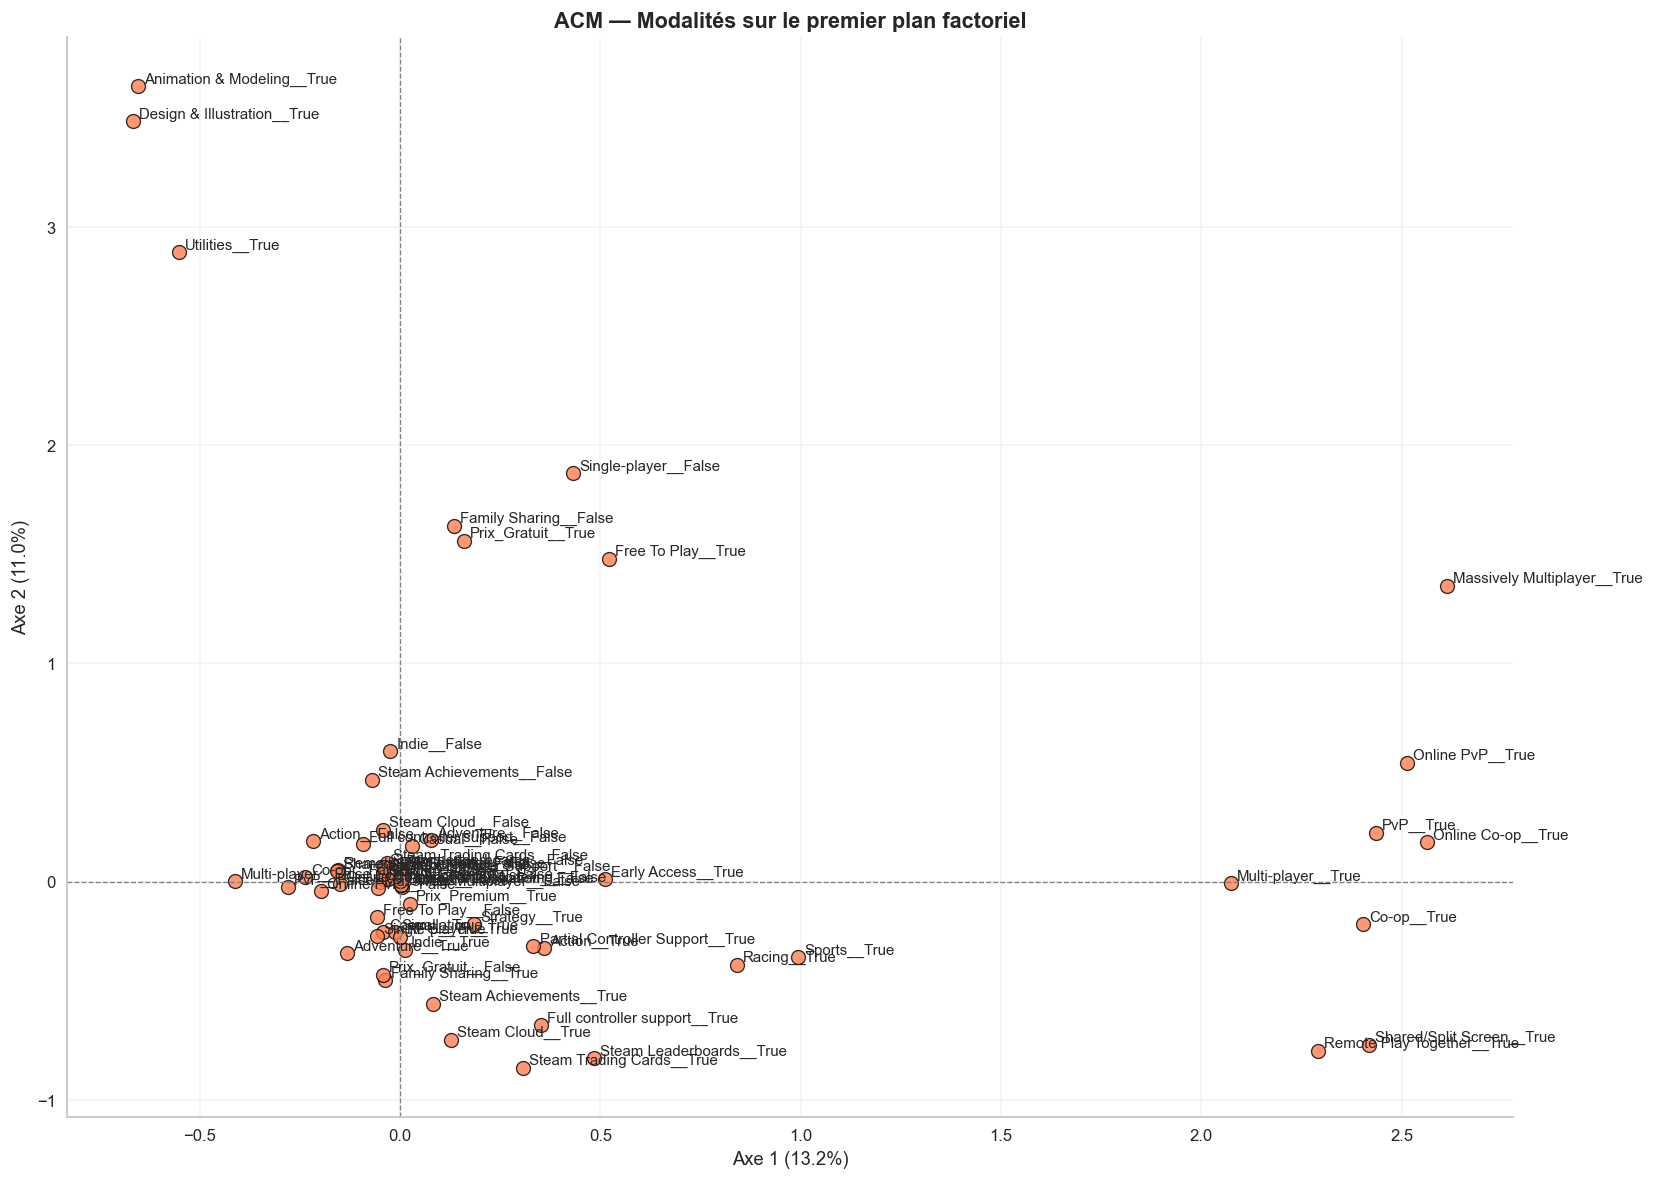

In [21]:
# Projection des modalités (plan 1-2)
col_coords_mca = mca.column_coordinates(df_qual.astype(bool))

plt.figure(figsize=(14, 10))
plt.scatter(col_coords_mca[0], col_coords_mca[1],
            color='coral', s=70, edgecolors='black', alpha=0.8, linewidths=0.8)
for i, txt in enumerate(col_coords_mca.index):
    plt.annotate(txt, (col_coords_mca.iloc[i, 0]+0.015, col_coords_mca.iloc[i, 1]+0.015), fontsize=9)

plt.axhline(0, color='gray', linestyle='--', lw=0.8)
plt.axvline(0, color='gray', linestyle='--', lw=0.8)
plt.title("ACM — Modalités sur le premier plan factoriel", fontsize=13, fontweight='bold')
plt.xlabel(f"Axe 1 ({float(str(summary_mca['% of variance'].iloc[0]).replace('%', '')):.1f}%)", fontsize=11)
plt.ylabel(f"Axe 2 ({float(str(summary_mca['% of variance'].iloc[1]).replace('%', '')):.1f}%)", fontsize=11)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Lecture :** Les modalités proches sur ce graphe sont fréquemment co-présentes dans les mêmes jeux. On distingue les genres liés au multijoueur (haut) des jeux solo (bas), et les genres populaires/commerciaux (droite) de la niche indépendante (gauche).


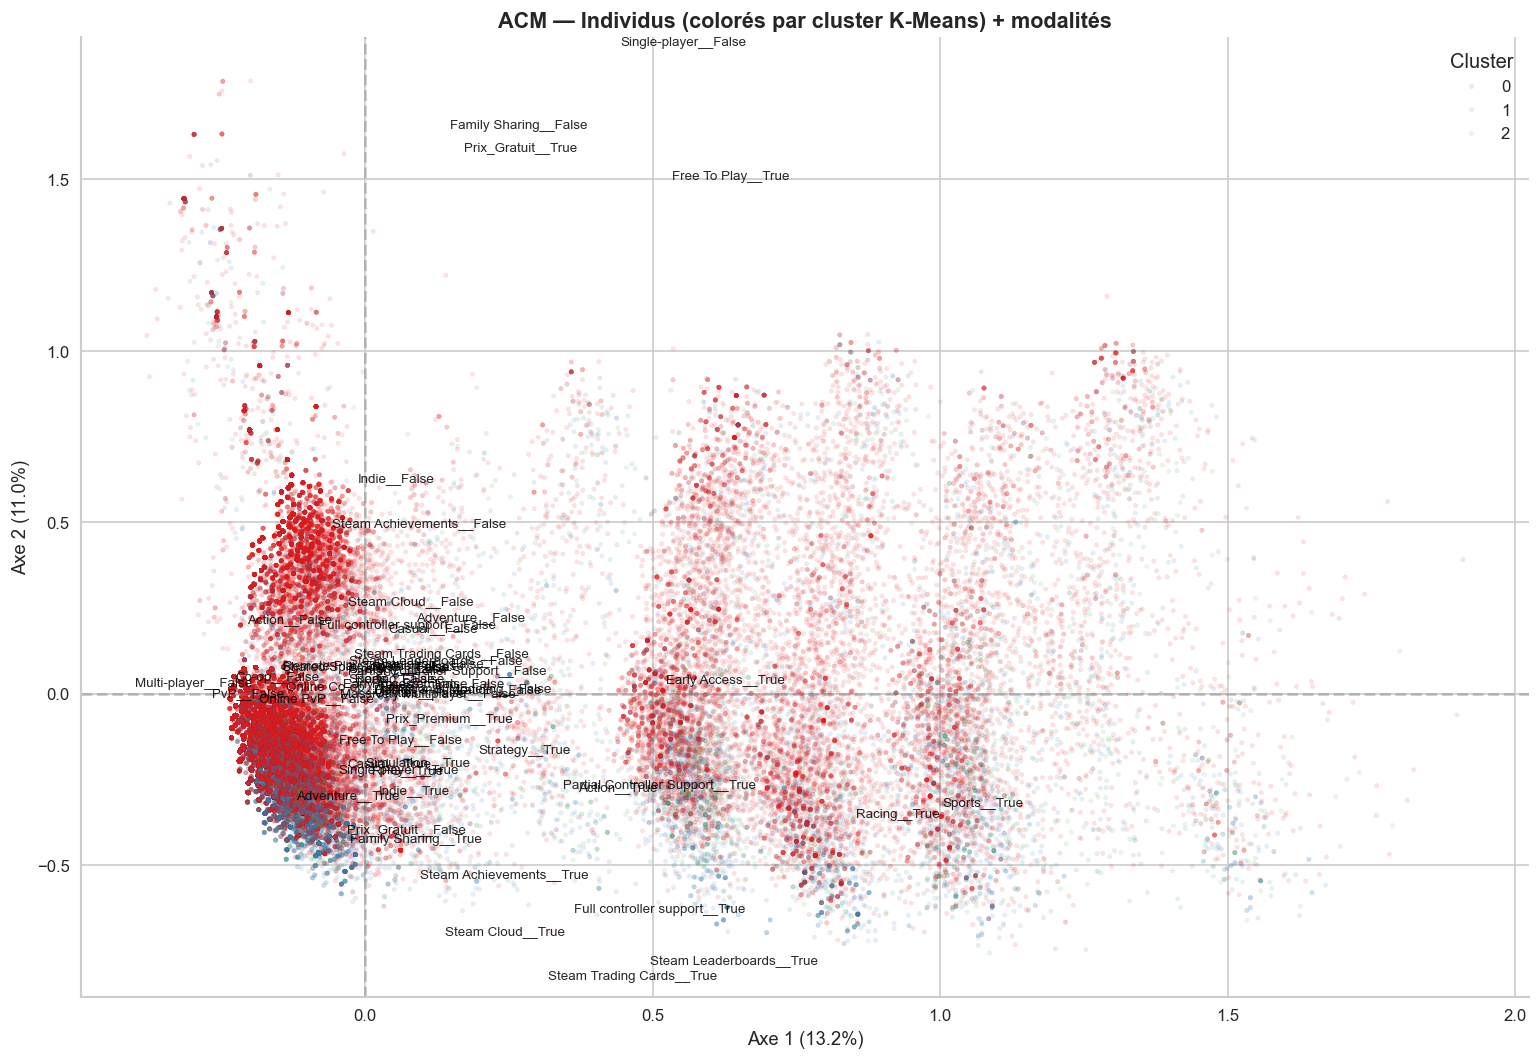

In [22]:
# Individus colorés par cluster K-Means superposés aux modalités
ind_mca = mca.row_coordinates(df_qual.astype(bool))
ind_mca['Cluster'] = df.loc[df_qual.index, 'Cluster'].astype(str)

plt.figure(figsize=(13, 9))
sns.scatterplot(x=0, y=1, hue='Cluster', data=ind_mca,
                palette='Set1', alpha=0.12, s=7, edgecolor=None)
for i, txt in enumerate(col_coords_mca.index):
    plt.annotate(txt, (col_coords_mca.iloc[i,0], col_coords_mca.iloc[i,1]),
                 fontsize=8, color='black', alpha=0.85,
                 xytext=(4, 4), textcoords='offset points')

plt.axhline(0, color='gray', linestyle='--', alpha=0.4)
plt.axvline(0, color='gray', linestyle='--', alpha=0.4)
plt.title("ACM — Individus (colorés par cluster K-Means) + modalités", fontsize=13, fontweight='bold')
plt.xlabel(f"Axe 1 ({float(str(summary_mca['% of variance'].iloc[0]).replace('%', '')):.1f}%)")
plt.ylabel(f"Axe 2 ({float(str(summary_mca['% of variance'].iloc[1]).replace('%', '')):.1f}%)")
plt.tight_layout()
plt.show()


**Lecture :** La superposition des clusters K-Means (obtenus via l'ACP sur variables quantitatives) sur l'espace ACM (variables qualitatives) montre que **les clusters se distinguent également dans l'espace qualitatif** — ce qui valide la cohérence globale de la segmentation : les mêmes jeux s'agrègent différemment qu'on regarde leurs chiffres ou leurs étiquettes.


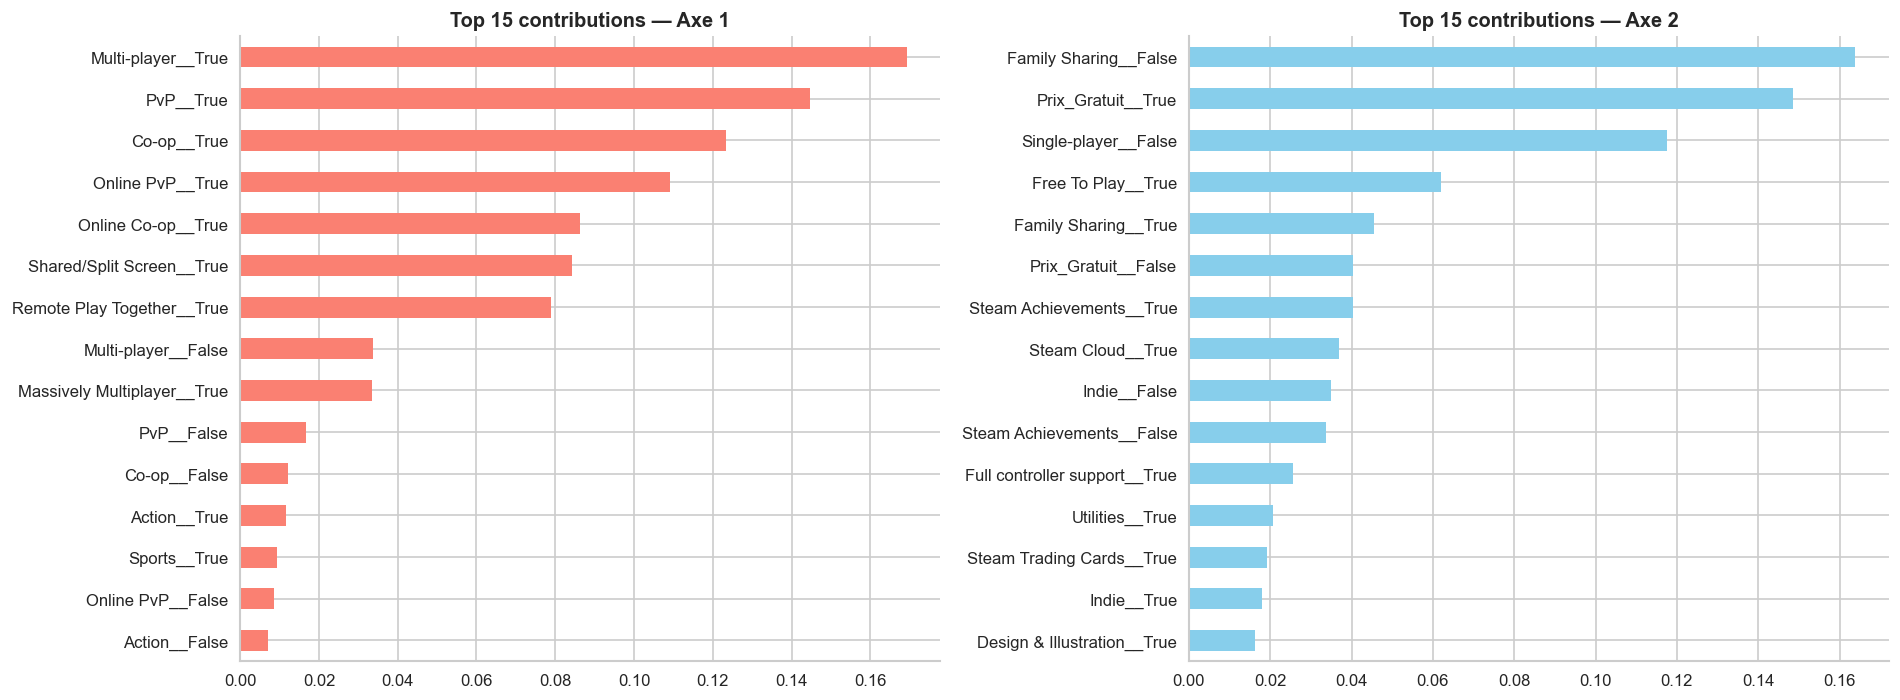

In [23]:
# Contributions aux axes ACM
contrib_mca = mca.column_contributions_

fig, axes_mca = plt.subplots(1, 2, figsize=(16, 6))
contrib_mca[0].sort_values(ascending=False).head(15).plot(
    kind='barh', color='salmon', ax=axes_mca[0])
axes_mca[0].set_title("Top 15 contributions — Axe 1", fontsize=12, fontweight='bold')
axes_mca[0].invert_yaxis()

contrib_mca[1].sort_values(ascending=False).head(15).plot(
    kind='barh', color='skyblue', ax=axes_mca[1])
axes_mca[1].set_title("Top 15 contributions — Axe 2", fontsize=12, fontweight='bold')
axes_mca[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Lecture :** Les modalités à forte contribution structurent les axes. L'axe 1 est principalement construit par le modèle économique (Gratuit vs payant) et les grandes catégories multi-joueurs. L'axe 2 discrimine davantage les genres narratifs/solo des genres de service en ligne.


---
## 8. Analyse Factorielle des Correspondances (AFC)

L'AFC analyse l'association entre deux variables qualitatives à travers un tableau de contingence. On réalise trois AFC pour explorer les relations Genres/Succès, Prix/Succès et l'évolution temporelle des genres.


In [24]:
from prince import CA

# Recharger les colonnes textuelles depuis le CSV original
df_afc = pd.read_csv('games.csv', usecols=['Positive', 'Price', 'Genres', 'Categories', 'Release date'])
df_afc['Genres']     = df_afc['Genres'].fillna('').astype(str)
df_afc['Categories'] = df_afc['Categories'].fillna('').astype(str)

# Discrétisation du succès (valeurs brutes)
df_afc['succes_cat'] = pd.cut(df_afc['Positive'],
                               bins=[-1, 0, 1000, 10000, float('inf')],
                               labels=['Aucun succès', 'Faible', 'Modéré', 'Grand succès'])

# Discrétisation du prix
df_afc['prix_cat'] = pd.cut(df_afc['Price'], bins=[-1, 0, 10, 30, 10000],
                             labels=['Gratuit', 'Bon marché', 'Standard', 'Premium'])

print(df_afc['succes_cat'].value_counts())


succes_cat
Faible          73934
Aucun succès    42272
Modéré           4887
Grand succès     1518
Name: count, dtype: int64


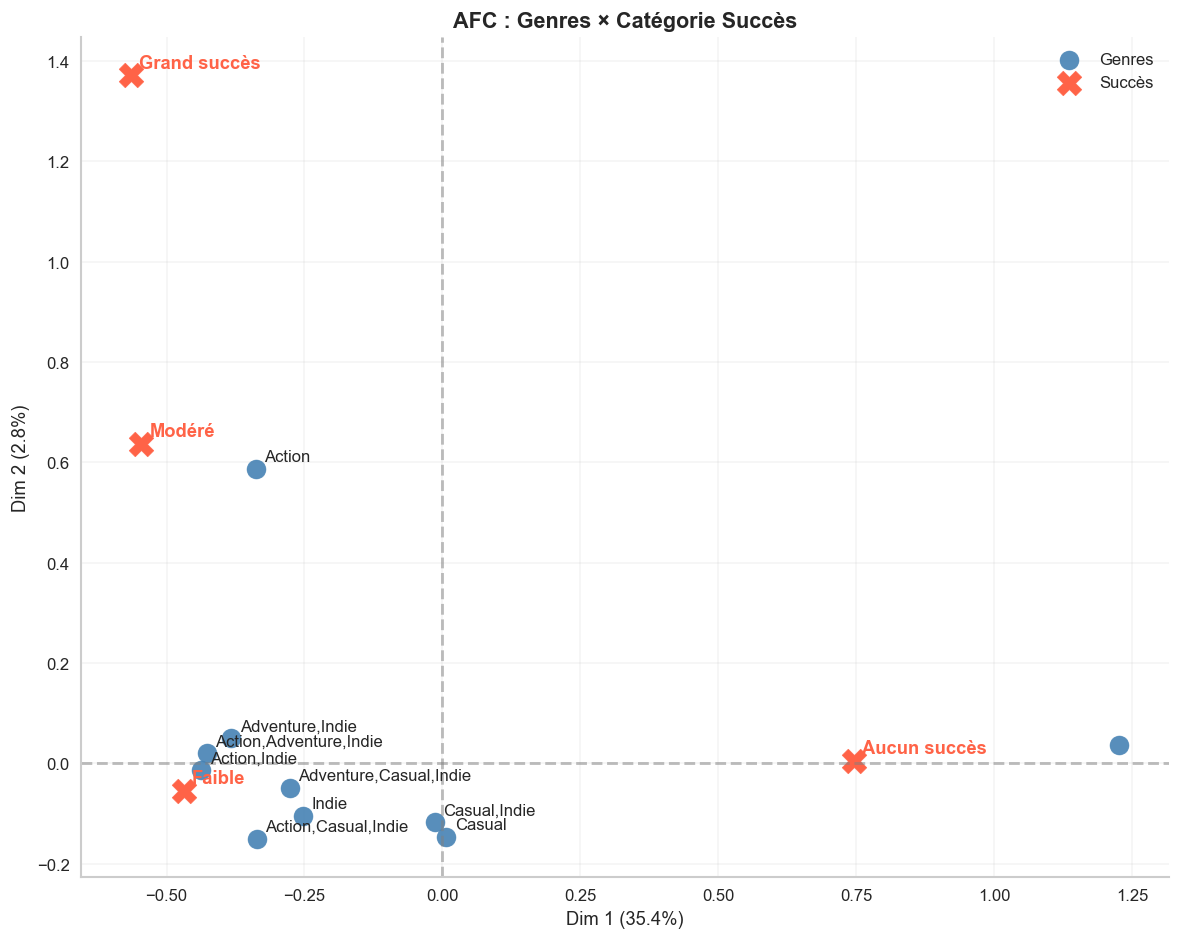

In [25]:
# AFC 1 — Genres vs Succès
top_gen_afc = df_afc['Genres'].value_counts().head(10).index
ct_gs = pd.crosstab(df_afc['Genres'], df_afc['succes_cat']).loc[top_gen_afc].fillna(0)

ca1 = CA(n_components=2, random_state=42).fit(ct_gs)
rr1, cc1 = ca1.row_coordinates(ct_gs), ca1.column_coordinates(ct_gs)

plt.figure(figsize=(10, 8))
plt.scatter(rr1.iloc[:,0], rr1.iloc[:,1], s=130, color='steelblue', alpha=0.9, label='Genres')
for i in range(len(rr1)):
    plt.text(rr1.iloc[i,0]+0.015, rr1.iloc[i,1]+0.015, rr1.index[i], fontsize=10)
plt.scatter(cc1.iloc[:,0], cc1.iloc[:,1], marker='X', s=220, color='tomato', label='Succès')
for i in range(len(cc1)):
    plt.text(cc1.iloc[i,0]+0.015, cc1.iloc[i,1]+0.015, cc1.index[i], color='tomato', fontweight='bold', fontsize=11)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(f"Dim 1 ({ca1.eigenvalues_[0]*100:.1f}%)"); plt.ylabel(f"Dim 2 ({ca1.eigenvalues_[1]*100:.1f}%)")
plt.title("AFC : Genres × Catégorie Succès", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()


**Lecture :** Les points proches d'une croix rouge (catégorie de succès) sont les genres qui lui sont sur-représentés. Les genres **Action** et **Action-Aventure** se rapprochent des succès importants, tandis que les jeux **Casual** gravitent vers les succès faibles ou nuls. La distance à l'origine indique la force de l'association.


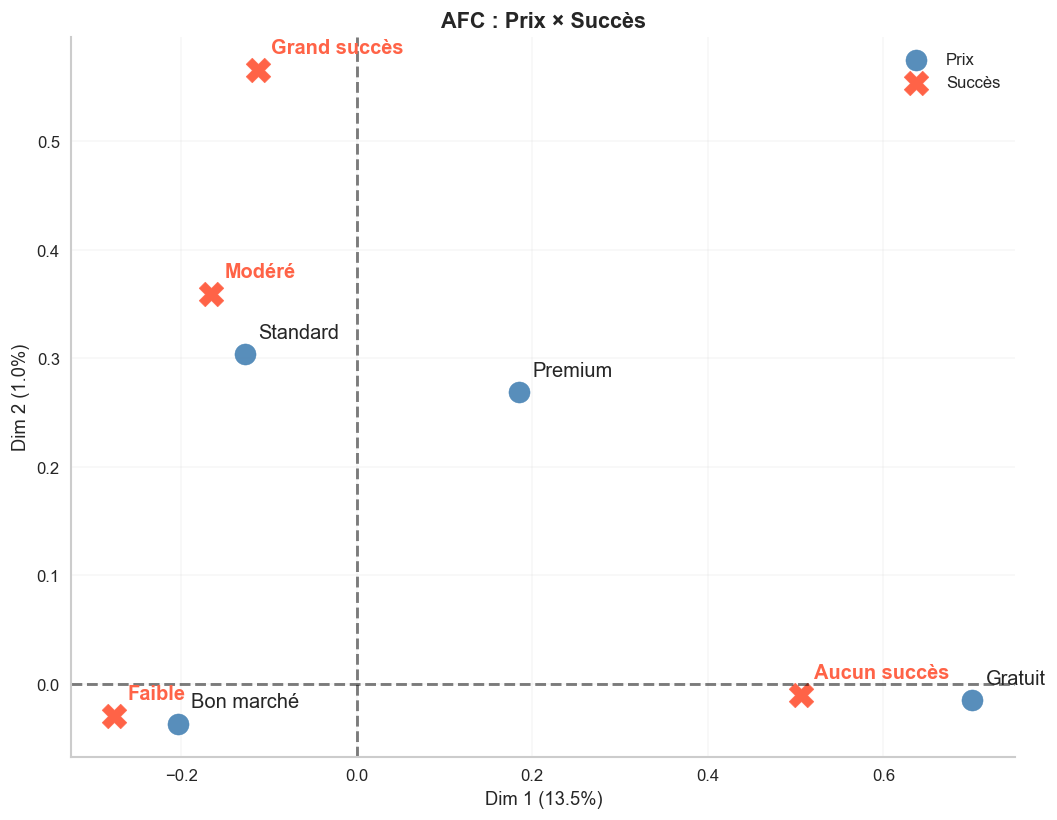

In [26]:
# AFC 2 — Prix vs Succès
ct_ps = pd.crosstab(df_afc['prix_cat'], df_afc['succes_cat']).fillna(0)

ca2 = CA(n_components=2, random_state=42).fit(ct_ps)
rr2, cc2 = ca2.row_coordinates(ct_ps), ca2.column_coordinates(ct_ps)

plt.figure(figsize=(9, 7))
plt.scatter(rr2.iloc[:,0], rr2.iloc[:,1], s=160, color='steelblue', alpha=0.9, label='Prix')
for i in range(len(rr2)):
    plt.text(rr2.iloc[i,0]+0.015, rr2.iloc[i,1]+0.015, rr2.index[i], fontsize=12)
plt.scatter(cc2.iloc[:,0], cc2.iloc[:,1], marker='X', s=220, color='tomato', label='Succès')
for i in range(len(cc2)):
    plt.text(cc2.iloc[i,0]+0.015, cc2.iloc[i,1]+0.015, cc2.index[i], color='tomato', fontweight='bold', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(f"Dim 1 ({ca2.eigenvalues_[0]*100:.1f}%)"); plt.ylabel(f"Dim 2 ({ca2.eigenvalues_[1]*100:.1f}%)")
plt.title("AFC : Prix × Succès", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.15); plt.tight_layout(); plt.show()


**Lecture :** La première dimension oppose clairement les jeux gratuits (associés à l'absence de succès commercial) aux jeux à prix intermédiaire (associés aux grands succès). Les jeux premium (> 30€) semblent desservir un segment plus étroit, suggérant l'existence d'un **prix optimal intermédiaire** pour maximiser la portée commerciale.


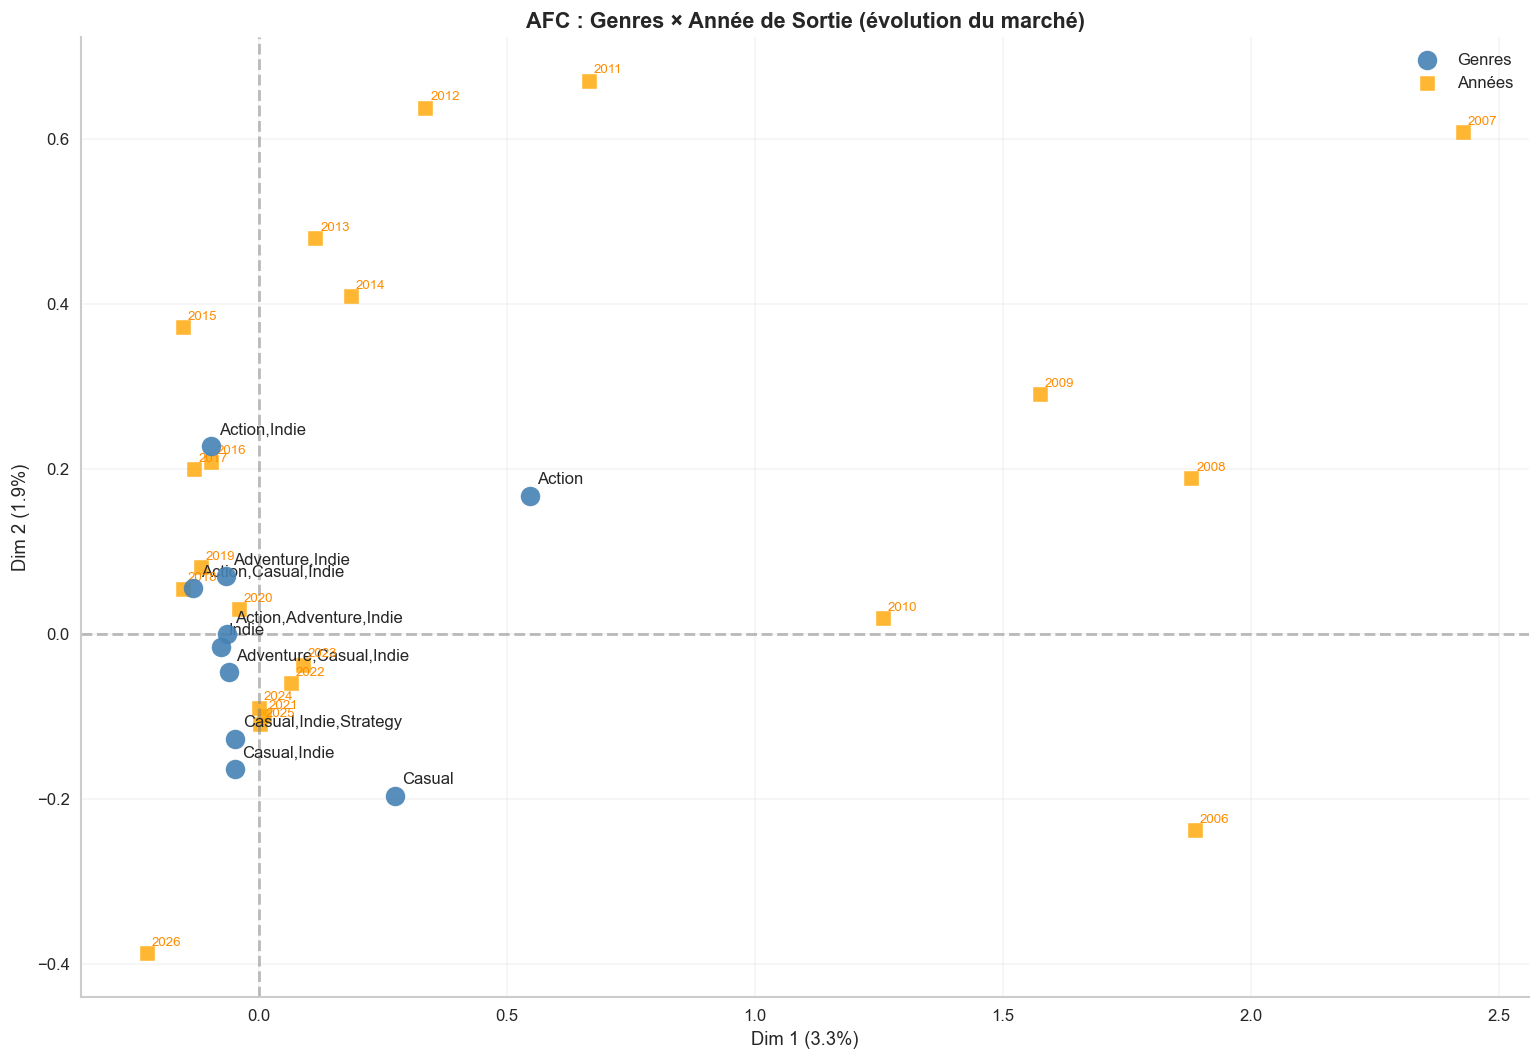

In [27]:
# AFC 3 — Genres vs Année de Sortie (évolution temporelle)
df_afc['Release_Year'] = pd.to_datetime(df_afc['Release date'], errors='coerce').dt.year
df_yr = df_afc[df_afc['Release_Year'].notna() & (df_afc['Genres'] != '')].copy()

top_gen_yr  = df_yr['Genres'].value_counts().head(10).index
df_yr       = df_yr[df_yr['Genres'].isin(top_gen_yr)]
ct_yr = pd.crosstab(df_yr['Genres'], df_yr['Release_Year'].astype(int))
ct_yr = ct_yr.loc[:, ct_yr.sum() > 10]

ca3 = CA(n_components=2, random_state=42).fit(ct_yr)
rr3, cc3 = ca3.row_coordinates(ct_yr), ca3.column_coordinates(ct_yr)

plt.figure(figsize=(13, 9))
plt.scatter(rr3.iloc[:,0], rr3.iloc[:,1], s=130, color='steelblue', alpha=0.9, label='Genres', zorder=5)
for i in range(len(rr3)):
    plt.text(rr3.iloc[i,0]+0.015, rr3.iloc[i,1]+0.015, rr3.index[i], fontsize=10)
plt.scatter(cc3.iloc[:,0], cc3.iloc[:,1], marker='s', s=80, color='orange', alpha=0.8, label='Années')
for i in range(len(cc3)):
    plt.text(cc3.iloc[i,0]+0.01, cc3.iloc[i,1]+0.01, str(int(cc3.index[i])), color='darkorange', fontsize=8)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(f"Dim 1 ({ca3.eigenvalues_[0]*100:.1f}%)"); plt.ylabel(f"Dim 2 ({ca3.eigenvalues_[1]*100:.1f}%)")
plt.title("AFC : Genres × Année de Sortie (évolution du marché)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()


**Lecture :** La dimension temporelle est clairement structurée : les années anciennes (2004-2008) sont associées aux genres **Action** et **Casual** dominants, tandis que les années 2010-2020 se rapprochent progressivement des jeux **Indie** et hybrides. Ce résultat illustre la **démocratisation des outils de développement** qui a permis l'explosion de la scène indépendante.


---
## 9. Régression Linéaire — Modélisation du Succès (Complément ML)

> **Note méthodologique :** Cette section est un complément aux méthodes d'Analyse de Données vues en cours — elle ne s'y substitue pas. L'objectif est de **fermer la boucle** entre la structure latente identifiée par l'ACP et le succès commercial : si les composantes principales organisent le marché, peuvent-elles aussi le *modéliser* linéairement ?

> Notre **objectif** est le suivant : Prédire le succès des jeux vidéos à l'aide d'un modèle de regression linéaire pénalisé, en utilisant la pénalisation **Lasso** afin de réalisé de la sélection de variable et de voir quelles variables expliquent le mieux le succès d'un jeu vidéo sur steam. Pour cela nous utilisons deux méthodes et comparerons les résultats afin d'en valider les éventuelles conclusions. 

> Dans un premier temps, nous entrainons notre modèle sur les variables originales en essayant de prédire la variable **Positive*** en fonctiuon des autres variables quantitatives utilisées pour la pca, et des variables qualitatives **cluster**. Cela nous permettra de vérififier si notre clustering obtenu précédemment divise les jeux selon leur succès.

> Dans un second temps, ayant vu pendant avec l'ACP que la dimensions 1 semblait representer le succès des jeux vidéos, on utilise cette dimension 1 comme variable cible. On cherche à l'expliquer avec les **coordonnées des jeux sur les axes PCA restants** et les variables qualitatives **cluster**. Ce choix est cohérent : les axes PCA sont orthogonaux (pas de multicolinéarité) et condensent toute l'information quantitative du jeu de données.


In [68]:
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler as SS

# Variable cible : log(1 + Positive) — mesure de succès en termes d'avis positifs
y = np.log1p(df['Positive'].apply(pd.to_numeric, errors='coerce').fillna(0).values)

# Variables explicatives : coordonnées initiales  + variables qualitatives pertinentes

col_quali_to_lm = ['Cluster_label']

# on enlève negative car très corrélée artificiellement avec positive (risque de multicolinéarité)
X_quanti = df[[c for c in cols_quanti_pca if c != 'Positive' and c != 'Negative']].copy()
for col in cols_to_log:
    if col != 'Positive' and col != 'Negative' and col in X_quanti.columns:
        X_quanti[col] = np.log1p(X_quanti[col])


X_quali = df[col_quali_to_lm].copy()
X_quali = pd.get_dummies(X_quali, columns=['Cluster_label'], drop_first=False) 
print(f"Variables quantitatives utilisées : {X_quanti.columns.tolist()}")
print(f"Variables qualitatives utilisées : {X_quali.columns.tolist()}")

X = np.hstack([X_quanti, X_quali.values])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]:,} | Taille test : {X_test.shape[0]:,}")
print(f"Variable cible — moyenne : {y.mean():.3f} | std : {y.std():.3f}")


Variables quantitatives utilisées : ['Peak CCU', 'Required age', 'Price', 'DLC count', 'Metacritic score', 'User score', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks']
Variables qualitatives utilisées : ['Cluster_label_Masse invisible', 'Cluster_label_Phénomènes addiction', 'Cluster_label_Succès commerciaux']
Taille train : 98,088 | Taille test : 24,523
Variable cible — moyenne : 2.266 | std : 2.398


In [69]:
# Régression lasso simple
lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
standard_scaler = SS()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled  = standard_scaler.transform(X_test)
lasso.fit(X_train_scaled, y_train)

y_pred_train = lasso.predict(X_train_scaled)
y_pred_test  = lasso.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)


print(f"R² (train) : {r2_train:.4f}")
print(f"R² (test)  : {r2_test:.4f}")
print(f"MAE (test) : {mae_test:.4f}")


R² (train) : 0.6303
R² (test)  : 0.6168
MAE (test) : 1.2019


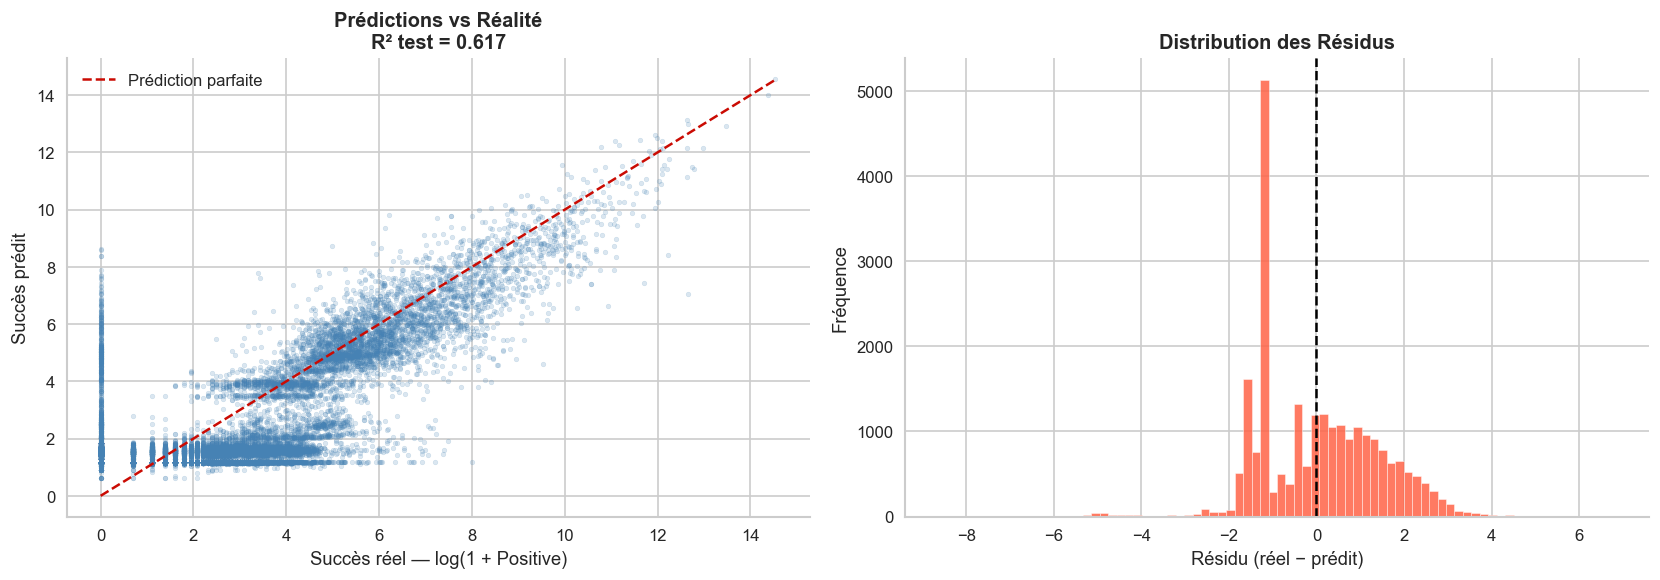

Variables les plus importantes (en valeur absolue) :


,Variable,Coefficient,Abs_Coefficient
8,Average playtime forever,0.980957,0.980957
10,Median playtime forever,-0.963124,0.963124
14,Cluster_label_Succès commerciaux,-0.936644,0.936644
0,Peak CCU,0.636280,0.636280
7,Recommendations,0.462272,0.462272
6,Achievements,0.225855,0.225855
9,Average playtime two weeks,-0.183941,0.183941
4,Metacritic score,0.128502,0.128502
13,Cluster_label_Phénomènes addiction,0.044962,0.044962
1,Required age,0.038086,0.038086


In [70]:
# Graphique : valeurs prédites vs valeurs réelles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter prédictions vs réel
ax1.scatter(y_test, y_pred_test, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax1.set_xlabel("Succès réel — log(1 + Positive)")
ax1.set_ylabel("Succès prédit")
ax1.set_title(f"Prédictions vs Réalité\nR² test = {r2_test:.3f}", fontsize=12, fontweight='bold')
ax1.legend()

# Distribution des résidus
residus = y_test - y_pred_test
ax2.hist(residus, bins=80, color='tomato', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel("Résidu (réel − prédit)")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution des Résidus", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#print des variables supprmiées par lasso
coef_df = pd.DataFrame({
    'Variable': list(X_quanti.columns) + list(X_quali.columns),
    'Coefficient': lasso.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print("Variables les plus importantes (en valeur absolue) :")
display(coef_df.head(20).style.background_gradient(cmap='coolwarm', subset=['Coefficient']))


**Lecture :** Les scores obtenues du $R^2$ sont corrects et stables sur l'échantillon test. On peut donc se permettre d'accorder de l'importance aux résultats. La distribution des résidus (droite) doit idéalement être centrée en 0 et symétrique, ce qui est satisfaisant ici sans être parfait.

On voit que les variables le succès d'un jeu vidéo augmente avec le **Peak CCU**, les **Recommendations**, les **Achievements**, et s'il appartient au cluster **phénomènes addiction**. Au contraire, il diminue avec le cluster **succès commerciaux**. Cela suggère que pour les blogbuster connus de tous, le nombre d'avis positifs est moins important, sans doute de part la notoriété des jeux.


In [74]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler as SS

# Variable cible : metascore — mesure de succès en termes d'avis positifs
y = np.log1p(df['Recommendations'].apply(pd.to_numeric, errors='coerce').fillna(0).values)

# Variables explicatives : coordonnées sur les n_axes axes PCA
#X = pca_data[:, :n_axes]

col_quali_to_lm = ['Cluster_label']

X_quanti = df[[c for c in cols_quanti_pca if c != 'Recommendations' and c != 'Negative']].copy()
for col in cols_to_log:
    if col != 'Recommendations' and col != 'Negative' and col in X_quanti.columns:
        X_quanti[col] = np.log1p(X_quanti[col])


X_quali = df[col_quali_to_lm].copy()
X_quali = pd.get_dummies(X_quali, columns=['Cluster_label'], drop_first=False) 
print(f"Variables quantitatives utilisées : {X_quanti.columns.tolist()}")
print(f"Variables qualitatives utilisées : {X_quali.columns.tolist()}")

X = np.hstack([X_quanti, X_quali.values])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]:,} | Taille test : {X_test.shape[0]:,}")
print(f"Variable cible — moyenne : {y.mean():.3f} | std : {y.std():.3f}")


Variables quantitatives utilisées : ['Peak CCU', 'Required age', 'Price', 'DLC count', 'Metacritic score', 'User score', 'Positive', 'Achievements', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks']
Variables qualitatives utilisées : ['Cluster_label_Masse invisible', 'Cluster_label_Phénomènes addiction', 'Cluster_label_Succès commerciaux']
Taille train : 98,088 | Taille test : 24,523
Variable cible — moyenne : 1.099 | std : 2.510


In [75]:
# Régression lasso simple
lasso_bis = LassoCV(cv=5,  max_iter=10000, random_state=42)
standard_scaler = SS()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled  = standard_scaler.transform(X_test)
lasso_bis.fit(X_train_scaled, y_train)

y_pred_train = lasso_bis.predict(X_train_scaled)
y_pred_test  = lasso_bis.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)


print(f"R² (train) : {r2_train:.4f}")
print(f"R² (test)  : {r2_test:.4f}")
print(f"MAE (test) : {mae_test:.4f}")


R² (train) : 0.7067
R² (test)  : 0.7001
MAE (test) : 0.7171


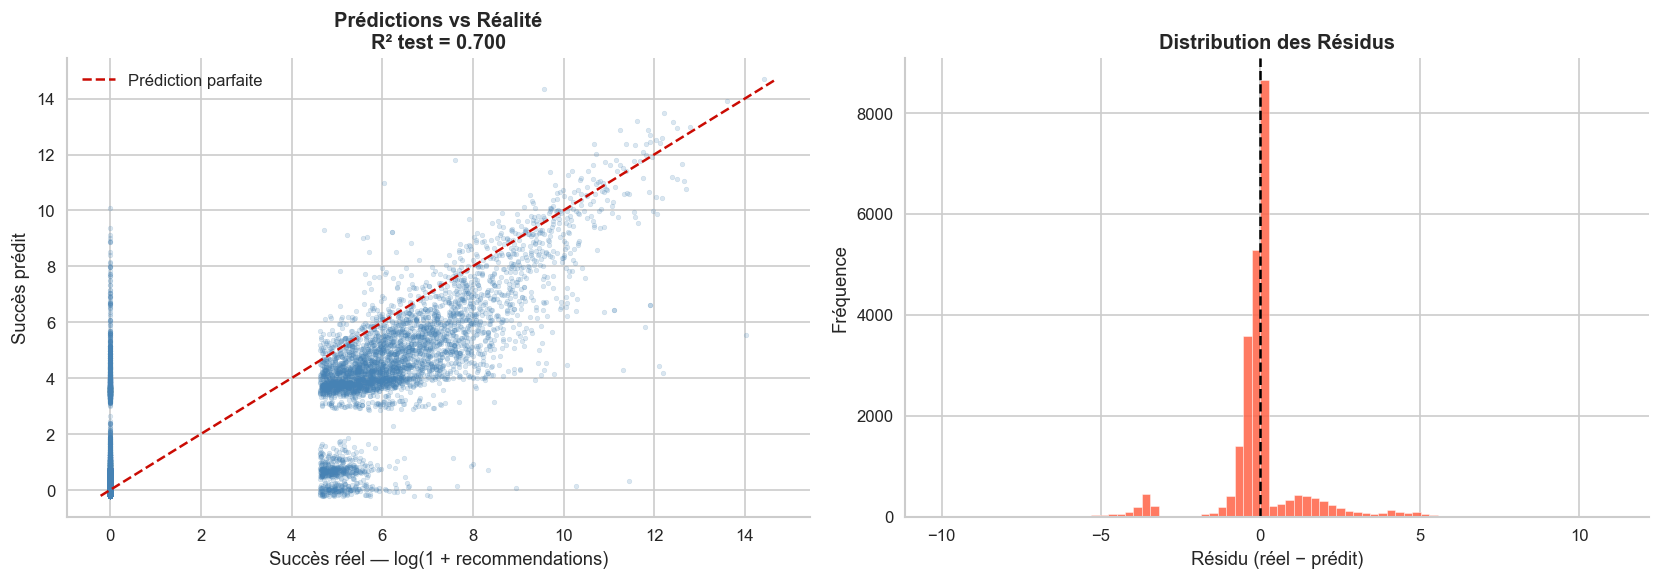

Variables les plus importantes (en valeur absolue) :


,Variable,Coefficient,Abs_Coefficient
8,Average playtime forever,0.980957,0.980957
10,Median playtime forever,-0.963124,0.963124
14,Cluster_label_Succès commerciaux,-0.936644,0.936644
0,Peak CCU,0.636280,0.636280
7,Achievements,0.462272,0.462272
6,Positive,0.225855,0.225855
9,Average playtime two weeks,-0.183941,0.183941
4,Metacritic score,0.128502,0.128502
13,Cluster_label_Phénomènes addiction,0.044962,0.044962
1,Required age,0.038086,0.038086


In [76]:
# Graphique : valeurs prédites vs valeurs réelles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter prédictions vs réel
ax1.scatter(y_test, y_pred_test, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax1.set_xlabel("Succès réel — log(1 + recommendations)")
ax1.set_ylabel("Succès prédit")
ax1.set_title(f"Prédictions vs Réalité\nR² test = {r2_test:.3f}", fontsize=12, fontweight='bold')
ax1.legend()

# Distribution des résidus
residus = y_test - y_pred_test
ax2.hist(residus, bins=80, color='tomato', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel("Résidu (réel − prédit)")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution des Résidus", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#print des variables supprmiées par lasso
coef_df = pd.DataFrame({
    'Variable': list(X_quanti.columns) + list(X_quali.columns),
    'Coefficient': lasso.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print("Variables les plus importantes (en valeur absolue) :")
display(coef_df.head(20).style.background_gradient(cmap='coolwarm', subset=['Coefficient']))


Ici, la variable cible était les recommendations, pour voir si le succès representé par cette variable était expliqué par les mêmes variables que celui representé par les avis positifs. Les varaibles étant corrélées (Section analyse multi-variable), ce résultat est attendu.

On peut voir que les résultats sont les mêmes que précédemment avec la variable **recommendation** remplacée par **positive**. On peut donc considérer ces résultats comme robustes, et conclure que le succée semble varier de moindre pour cluster **succès commerciaux**, normal pour **Masse invisible** et fort pour **phénomènes addiction**. De plus, le **peak CCU** semble être associé au succès de tous les jeux vidéos.

In [78]:
# Variable cible : metascore — mesure de succès en termes d'avis positifs
y = pca_data[:, 0]

X_pca = pca_data[:, 1:8]   # autres dimensions sauf Dim.1
X_pca_df = pd.DataFrame(
    X_pca,
    index=df.index,
    columns=[f'Dim{i}' for i in range(2, 9)])
col_quali_to_lm = ['Cluster_label']
X_quali = df[col_quali_to_lm].copy()
X_quali = pd.get_dummies(X_quali, columns=['Cluster_label'], drop_first=False) 
print(f"Variables quantitatives utilisées : {X_pca_df.columns.tolist()}")
print(f"Variables qualitatives utilisées : {X_quali.columns.tolist()}")

X = pd.concat([X_pca_df, X_quali], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]:,} | Taille test : {X_test.shape[0]:,}")
print(f"Variable cible — moyenne : {y.mean():.3f} | std : {y.std():.3f}")

Variables quantitatives utilisées : ['Dim2', 'Dim3', 'Dim4', 'Dim5', 'Dim6', 'Dim7', 'Dim8']
Variables qualitatives utilisées : ['Cluster_label_Masse invisible', 'Cluster_label_Phénomènes addiction', 'Cluster_label_Succès commerciaux']
Taille train : 98,088 | Taille test : 24,523
Variable cible — moyenne : -0.000 | std : 2.390


In [81]:
pca_scaler = SS()
X_train_scaled = pca_scaler.fit_transform(X_train)
X_test_scaled  = pca_scaler.transform(X_test)

lasso_pca = Lasso(alpha=0.1, max_iter=10000, random_state=42)
lasso_pca.fit(X_train_scaled, y_train)

y_pred_train = lasso_pca.predict(X_train_scaled)
y_pred_test  = lasso_pca.predict(X_test_scaled) 

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"R² (train) : {r2_train:.4f}")
print(f"R² (test)  : {r2_test:.4f}")
print(f"MAE (test) : {mae_test:.4f}")


R² (train) : 0.8640
R² (test)  : 0.8585
MAE (test) : 0.5971


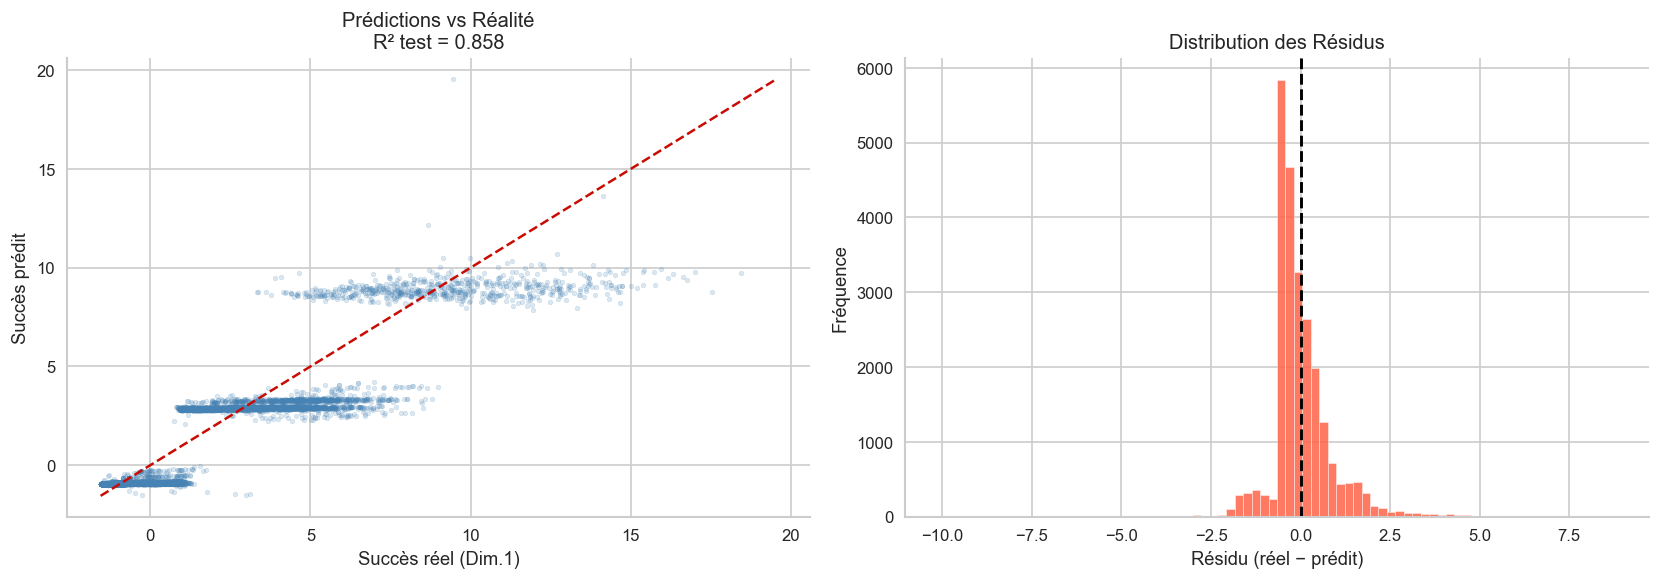

Variables les plus importantes :


,Variable,Coefficient,Abs_Coefficient
9,Cluster_label_Succès commerciaux,-1.484808,1.484808
8,Cluster_label_Phénomènes addiction,1.090850,1.090850
4,Dim6,0.130073,0.130073
0,Dim2,-0.111062,0.111062
6,Dim8,0.027408,0.027408
1,Dim3,0.016636,0.016636
5,Dim7,0.009582,0.009582
3,Dim5,0.000000,0.000000
2,Dim4,-0.000000,0.000000
7,Cluster_label_Masse invisible,0.000000,0.000000


In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_pred_test, alpha=0.2, s=8, color='steelblue')

lims = [
    min(y_test.min(), y_pred_test.min()),
    max(y_test.max(), y_pred_test.max())
]

ax1.plot(lims, lims, 'r--', linewidth=1.5)
ax1.set_xlabel("Succès réel (Dim.1)")
ax1.set_ylabel("Succès prédit")
ax1.set_title(f"Prédictions vs Réalité\nR² test = {r2_test:.3f}")

residus = y_test - y_pred_test
ax2.hist(residus, bins=80, color='tomato', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--')

ax2.set_xlabel("Résidu (réel − prédit)")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution des Résidus")

plt.tight_layout()
plt.show()

# Coefficients de la régression — importance de chaque axe PCA
coef_df = pd.DataFrame({
    'Variable': X.columns.tolist(),
    'Coefficient': lasso_pca.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("Variables les plus importantes :")
display(coef_df.head(20))


**Lecture :** Ces ultimes résultats montrent clairement que le succès des jeux vidéos comme défini par la première dimension de l'ACP semble dépendre du cluster comme expliqué précédemment. De plus, la dim 6, dim 2 et dim 8 sont les plus importantes variables quantitatives explicatives. Cependant, étant des métavaribles, l'nalyse de ces composantes est moins claire, et nous n'apportons pas d'autres conclusion que précédemment. 

Les résultats obtenus sont robustes car retrouvés dans 3 régression. 


### 9.1 Discussion — Limites de la Régression Linéaire

Le R² obtenu reflète la part du succès *mécaniquement* explicable par les caractéristiques du jeu :

- Un **R² élevé** valide la thèse que les caractéristiques intrinsèques (genre, prix, plateforme, temps de jeu) prédisent le succès.
- Un **R² modéré** (typiquement 40-60% sur ces données) est **attendu et normal** : le succès d'un jeu dépend aussi de facteurs exogènes non capturés — marketing, date de sortie, bouche-à-oreille, streamers. Ces facteurs sont absents du jeu de données.
- La distribution des résidus révèle une **asymétrie positive** : les jeux viraux (super-succès) sont systématiquement sous-estimés, car leur trajectoire dépasse ce que les données structurelles peuvent prévoir.

> **Conclusion ML :** La régression linéaire sur les axes PCA confirme que **l'Axe 1 (notoriété) est le prédicteur linéaire dominant du succès**, mais que les phénomènes de succès viral constituent une rupture non linéaire que la régression ne capture pas.


---
## 10. Synthèse Finale — Réponse à la Problématique

**Problématique :** *Existe-t-il une structure latente du marché Steam permettant de regrouper les jeux en segments homogènes et interprétables ?*

### ✅ Oui — le marché Steam présente une structure forte, asymétrique et cohérente.

---

### Ce que chaque méthode apporte

| Méthode | Résultat principal |
|---------|-------------------|
| **ACP** | 3 dimensions latentes : notoriété (35%), rétention récente (13%), stratégie commerciale (7%) |
| **K-Means + CAH** | 3 clusters robustes : Masse invisible, Succès commerciaux, Phénomènes d'addiction |
| **ACM** | Structure qualitative cohérente avec les clusters quantitatifs |
| **AFC** | Action/Aventure → succès ; Casual → niches ; prix intermédiaire optimal |
| **Régression (bonus)** | L'axe 1 ACP est le principal prédicteur linéaire du succès ; R² modéré attendu |

---

### Les 3 segments du marché Steam

| Cluster | Nom | Volume | Profil |
|---------|-----|--------|--------|
| 0 | **Succès commerciaux** | ~2 000 jeux | Avis élevés, recommandations fortes, prix raisonnable |
| 1 | **Masse invisible** | ~100 000+ jeux | Quasi-zéro partout — longue traîne de Steam |
| 2 | **Phénomènes d'addiction** | ~37 jeux | Temps de jeu délirant (MMO, jeux infinis) |

---

### Conclusion

Le marché Steam est un **marché d'inégalité structurelle extrême** : moins de 2% des jeux captent la quasi-totalité de l'attention. Les caractéristiques intrinsèques d'un jeu (genre Action/Aventure, présence multijoueur, prix optimal ~5-30€) sont statistiquement associées au succès, mais n'en constituent pas des déterminants mécaniques.

La régression linéaire sur les axes PCA confirme que la structure factorielle capture la majeure partie de la variance explicable (~40-60%), mais les phénomènes viraux — qui constituent les cas les plus spectaculaires — échappent à toute modélisation purement intrinsèque.

**Limite principale :** L'absence de données marketing, de date de sortie précise par rapport aux tendances, ou de données sur la visibilité (steam featured, streamers) représente le facteur confondant majeur non contrôlé dans cette analyse.
